# Wind CFD Surrogate — Physics-Informed MeshGraphNet v10
## v10 Fixes: OOM (GradientCheckpointing) | U MAE (SeparateDecoders) | Outliers (EDA-based tighter clip)
---
**v10 Changes (on top of v9):**
- **[FIX-OOM]** Gradient checkpointing in all 10 MP layers → O(1) activation memory instead of O(layers)
- **[FIX-U1]** Separate `decoder_p` and `decoder_U` heads → specialized pathways → lower U MAE
- **[FIX-U2]** Per-channel loss weights: Ux/Uy get 1.5x → model focuses more on velocity
- **[EDA-1]** Tighter outlier clip: 1.0–99.0% (was 0.5–99.5%) — EDA shows heavy tails in p/U
- **[EDA-2]** Uz-specific clip: 2.0–98.0% — Uz is near-zero dominated (EDA §2, §9)
- **Node dims: 20** | **39 cases as-is** | **No angle changes**


## 0 — Install Dependencies

In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip('torch_geometric')
pip('trimesh')
pip('matplotlib', 'numpy', 'scipy', 'tqdm', 'scikit-learn')

print('Dependencies ready')

Dependencies ready


## 1 — Imports & Device Setup

In [2]:
import os, re, json, math, time, random, hashlib
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import trimesh
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ──────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU  = torch.cuda.device_count()
print(f'Device: {DEVICE}  |  GPUs: {N_GPU}')
for i in range(N_GPU):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Device: cuda  |  GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2 — Configuration
> **Kaggle dataset structure expected:**
> ```
> /kaggle/input/<your-dataset>/
>   mohali_autumn/building1/{0/, 4000/, constant/}
>   dublin_spring/building2/{0/, 2000/, constant/}
>   ...
> ```

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────
DATASET_ROOT = Path('/kaggle/input/datasets/kunal320/dataset/mohali_dataset')
CACHE_DIR    = Path('/kaggle/working/cache')
OUTPUT_DIR   = Path('/kaggle/working/output')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Physics constants (air, 20°C) ─────────────────────────────────────────
NU    = 1.5e-5    # kinematic viscosity [m²/s]
RHO   = 1.225     # air density [kg/m³]
P_REF = 101325.0  # atmospheric reference [Pa]
P_GAUGE_NORM = True

# ── [EDA-1] Outlier clipping — tighter bounds based on EDA kurtosis analysis ──
# EDA §7 shows heavy tails (kurtosis > 5) in p_gauge and Ux/Uy → tighter clip
CLIP_LOW_PCT  = 1.0   # was 0.5 → EDA shows significant outliers beyond ±2.5σ
CLIP_HIGH_PCT = 99.0  # was 99.5 → symmetric tightening

# [EDA-2] Uz separate: EDA §2 shows Uz≈0 for >50% cells (near-zero dominated)
# Very tight clip avoids numerical artifacts inflating Uz_std
UZ_CLIP_LOW_PCT  = 2.0
UZ_CLIP_HIGH_PCT = 98.0

# ── [PRE-4] ABL (Atmospheric Boundary Layer) power-law ─────────────────────
ABL_ALPHA = 0.25
ABL_Z_REF = 10.0

# ── [PRE-6] Gradient-weighted loss ─────────────────────────────────────────
GRAD_WEIGHT_K = 3.0   # max weight multiplier for high-gradient cells

# ── [FIX-U2] Per-channel loss weights [p, Ux, Uy, Uz] ─────────────────────
# Model predicts p well but U poorly → boost Ux/Uy channels in loss
# Uz stays 1.0 since it's near-zero and already easy to learn
CHANNEL_WEIGHTS = [1.0, 1.5, 1.5, 1.0]

# ── Graph construction ─────────────────────────────────────────────────────
K_NEIGHBORS = 8
MAX_CELLS   = 20000

# ── Model architecture ─────────────────────────────────────────────────────
HIDDEN_DIM  = 96
LATENT_DIM  = 96
N_MP_LAYERS = 10
OUT_DIM     = 4       # [p, Ux, Uy, Uz]

# ── Training ───────────────────────────────────────────────────────────────
EPOCHS         = 400
BATCH_SIZE     = 1
LR             = 3e-4
LR_DECAY       = 0.5
LR_PATIENCE    = 25
WEIGHT_DECAY   = 1e-5
PHYSICS_WEIGHT = 0.15
GRAD_CLIP      = 1.0
EARLY_STOP_PAT = 60

# ── [v7] Physics sub-weights ───────────────────────────────────────────────
NEUMANN_P_WEIGHT = 0.10
CURL_WEIGHT      = 0.05
BC_LOSS_WEIGHT   = 0.15

# ── Split ──────────────────────────────────────────────────────────────────
VAL_FRAC  = 0.15
TEST_FRAC = 0.10

# ── Inference diagnostics ──────────────────────────────────────────────────
WEAK_ZONE_FRAC    = 0.30
WAKE_SPEED_FRAC   = 0.60
WAKE_DOWNSTREAM_M = 0.0
BL_HEIGHT_M       = 2.0

print('Configuration loaded (v10 — OOM + U MAE + Outlier fixes).')
print(f'  MAX_CELLS={MAX_CELLS}  K={K_NEIGHBORS}  Layers={N_MP_LAYERS}')
print(f'  Hidden={HIDDEN_DIM}  Epochs={EPOCHS}  Physics_w={PHYSICS_WEIGHT}')
print(f'  [EDA-1] Outlier clip p/U: [{CLIP_LOW_PCT}%, {CLIP_HIGH_PCT}%]')
print(f'  [EDA-2] Outlier clip Uz:  [{UZ_CLIP_LOW_PCT}%, {UZ_CLIP_HIGH_PCT}%]')
print(f'  [FIX-U2] Channel weights: {CHANNEL_WEIGHTS}')
print(f'  [FIX-OOM] Gradient checkpointing: ENABLED')
print(f'  [FIX-U1] Separate p/U decoder heads: ENABLED')


Configuration loaded (v10 — OOM + U MAE + Outlier fixes).
  MAX_CELLS=20000  K=8  Layers=10
  Hidden=96  Epochs=400  Physics_w=0.15
  [EDA-1] Outlier clip p/U: [1.0%, 99.0%]
  [EDA-2] Outlier clip Uz:  [2.0%, 98.0%]
  [FIX-U2] Channel weights: [1.0, 1.5, 1.5, 1.0]
  [FIX-OOM] Gradient checkpointing: ENABLED
  [FIX-U1] Separate p/U decoder heads: ENABLED


## 3 — OpenFOAM Parsers (All Bugs Fixed)

### Fixes applied:
- **[C-2]** Scalar parser: uses declared count N, reads from `(` to `\n)\n` — no regex trap on `)` inside header  
- **[C-3]** Vector parser: finds count in header, extracts exactly N tuples from data body only  
- **[H-1]** `n_cells` from `nCells:` in owner note header (not `max(owner)+1`)  
- **[H-2]** Face regex anchored to data body start after `// *` separator  
- **[M-1]** `.replace('\\r','')` before `np.fromstring` — handles Windows line endings  
- **[L-1]** Removed dead `_read_foam_header_n`  
- **BOUNDARY** `parse_boundary_patches` → per-cell boundary type flags

In [4]:
# ─────────────────────────────────────────────────────────────────────────
# Helper: robust OpenFOAM list parser
# ─────────────────────────────────────────────────────────────────────────

def _foam_body(text: str) -> Tuple[str, int]:
    """Return (body_text, count) for any OpenFOAM list.
    Finds the '\n(\n' after the separator '// *', extracts count from the
    integer on the line just before '('.
    """
    # [M-1] normalize line endings
    text = text.replace('\r', '')
    # Find data block: last '// *...' separator, then count\n(
    sep = text.find('// *')
    after = text[sep:]
    m = re.search(r'(\d+)\s*\n\(', after)
    if not m:
        raise ValueError('Cannot find list count in foam file')
    count = int(m.group(1))
    start = sep + m.end()   # position right after '('
    end   = text.find('\n)\n', start)
    if end == -1:
        end = text.find('\n)', start)
    return text[start:end], count


def _count_cells_from_owner(owner_file: Path) -> int:
    """[H-1] Get nCells from header note — reliable, no max() trick."""
    text = owner_file.read_text(errors='ignore')
    m = re.search(r'nCells:(\d+)', text)
    if m:
        return int(m.group(1))
    # fallback: owner.max()+1 (less reliable but works for standard meshes)
    body, _ = _foam_body(text)
    arr = np.fromstring(body, sep='\n', dtype=np.int32)
    return int(arr.max()) + 1


def parse_foam_scalar(filepath: Path) -> np.ndarray:
    """[C-2] Parse volScalarField → ndarray (N,).
    Uses declared N and positional extraction — no [^)]+ trap.
    """
    text = filepath.read_text(errors='ignore').replace('\r', '')

    # nonuniform: find count, then parse from ( to \n)\n
    m = re.search(
        r'internalField\s+nonuniform\s+List<scalar>\s+(\d+)\s*\(',
        text
    )
    if m:
        n     = int(m.group(1))
        start = m.end()
        end   = text.find('\n)\n', start)
        if end == -1:
            end = text.find('\n)', start)
        body  = text[start:end]
        return np.fromstring(body, sep='\n', dtype=np.float32)[:n]

    # uniform fallback
    m2 = re.search(r'internalField\s+uniform\s+([\d.e+\-]+)', text)
    if m2:
        owner_file = filepath.parent.parent / 'constant' / 'polyMesh' / 'owner'
        n = _count_cells_from_owner(owner_file)
        return np.full(n, float(m2.group(1)), dtype=np.float32)

    raise ValueError(f'Cannot parse scalar: {filepath}')


def parse_foam_vector(filepath: Path) -> np.ndarray:
    """[C-3] Parse volVectorField → ndarray (N, 3).
    Finds count in header, then extracts exactly N tuples from data body.
    """
    text = filepath.read_text(errors='ignore').replace('\r', '')

    # nonuniform: find header count, then data body
    m = re.search(
        r'internalField\s+nonuniform\s+List<vector>\s+(\d+)\s*\(',
        text
    )
    if m:
        n     = int(m.group(1))
        start = m.end()    # right after '(' — data body starts here
        # Extract exactly n tuples; stop before boundary field
        tuples = re.findall(r'\(([^)]+)\)', text[start:])[:n]
        return np.array(
            [list(map(float, t.split())) for t in tuples],
            dtype=np.float32
        )

    # uniform fallback
    m2 = re.search(r'internalField\s+uniform\s+\(([^)]+)\)', text)
    if m2:
        vec = np.array(list(map(float, m2.group(1).split())), dtype=np.float32)
        owner_file = filepath.parent.parent / 'constant' / 'polyMesh' / 'owner'
        n = _count_cells_from_owner(owner_file)
        return np.tile(vec, (n, 1))

    raise ValueError(f'Cannot parse vector: {filepath}')


def parse_foam_labellist(filepath: Path, dtype=np.int32) -> np.ndarray:
    """Parse a raw OpenFOAM label list (owner, neighbour, etc.)"""
    text = filepath.read_text(errors='ignore')
    body, count = _foam_body(text)
    return np.fromstring(body, sep='\n', dtype=dtype)[:count]


def parse_foam_points(filepath: Path) -> np.ndarray:
    """Parse polyMesh/points → (N_pts, 3) float32."""
    text = filepath.read_text(errors='ignore').replace('\r', '')
    body, count = _foam_body(text)
    tuples = re.findall(r'\(([^)]+)\)', body)[:count]
    return np.array([list(map(float, t.split())) for t in tuples],
                    dtype=np.float32)


def parse_boundary_patches(mesh_dir: Path) -> Dict[str, Dict]:
    """Parse constant/polyMesh/boundary → dict of patch metadata."""
    text = (mesh_dir / 'boundary').read_text(errors='ignore')
    patches = {}
    for m in re.finditer(
        r'(\w+)\s*\{[^}]*?type\s+(\w+);[^}]*?nFaces\s+(\d+);[^}]*?startFace\s+(\d+);',
        text, re.DOTALL
    ):
        patches[m.group(1)] = {
            'type':      m.group(2),
            'nFaces':    int(m.group(3)),
            'startFace': int(m.group(4)),
        }
    return patches


def compute_cell_centers(case_dir: Path) -> Tuple[np.ndarray, Dict]:
    """[H-1, H-2] Compute cell centers + boundary cell sets.

    Returns:
        cell_centers : (n_cells, 3) float32
        boundary_cells: dict mapping patch name → set of cell indices
    """
    mesh_dir = case_dir / 'constant' / 'polyMesh'

    # ── Points ────────────────────────────────────────────────────────────
    points = parse_foam_points(mesh_dir / 'points')   # (n_pts, 3)

    # ── Faces → face centers ──────────────────────────────────────────────
    # [H-2] Use _foam_body to anchor regex to data body only
    faces_text = (mesh_dir / 'faces').read_text(errors='ignore').replace('\r', '')
    body_f, n_faces = _foam_body(faces_text)
    # Each face line: N(i j k l ...) — regex confined to body
    face_entries = re.findall(r'\d+\(([^)]+)\)', body_f)[:n_faces]
    face_centers = np.array(
        [points[list(map(int, e.split()))].mean(axis=0) for e in face_entries],
        dtype=np.float32
    )

    # ── Owner / Neighbour ─────────────────────────────────────────────────
    owner     = parse_foam_labellist(mesh_dir / 'owner')
    neighbour = parse_foam_labellist(mesh_dir / 'neighbour')
    n_internal = len(neighbour)
    n_cells    = _count_cells_from_owner(mesh_dir / 'owner')   # [H-1]

    # ── Accumulate face-center averages per cell ──────────────────────────
    cell_sum = np.zeros((n_cells, 3), dtype=np.float64)
    cell_cnt = np.zeros(n_cells, dtype=np.int32)
    # [FIX-B2] Use actual parsed face count — avoids broadcastable error
    n_fc    = len(face_centers)  # actual parsed (may be < n_faces)
    safe_nf = min(n_fc, len(owner))
    safe_ni = min(min(n_internal, n_fc), len(face_centers))
    np.add.at(cell_sum, owner[:safe_nf],    face_centers[:safe_nf])
    np.add.at(cell_cnt, owner[:safe_nf],    1)
    np.add.at(cell_sum, neighbour[:safe_ni], face_centers[:safe_ni])
    np.add.at(cell_cnt, neighbour[:safe_ni], 1)
    cell_centers = (cell_sum / np.maximum(cell_cnt[:, None], 1)).astype(np.float32)

    # ── Boundary cell sets ────────────────────────────────────────────────
    patches = parse_boundary_patches(mesh_dir)
    boundary_cells = {}
    for name, p in patches.items():
        s, nf = p['startFace'], p['nFaces']
        boundary_cells[name] = set(owner[s:s + nf].tolist())

    return cell_centers, boundary_cells


def build_owner_neighbour_edges(mesh_dir: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Return (src, dst) arrays for all internal faces (bidirectional)."""
    owner     = parse_foam_labellist(mesh_dir / 'owner')
    neighbour = parse_foam_labellist(mesh_dir / 'neighbour')
    n_internal = len(neighbour)
    src = np.concatenate([owner[:n_internal], neighbour])
    dst = np.concatenate([neighbour, owner[:n_internal]])
    return src, dst


def _find_converged_timestep(case_dir: Path) -> Optional[Path]:
    """Return path to the highest numeric (converged) timestep directory."""
    candidates = []
    for d in case_dir.iterdir():
        if d.is_dir() and re.fullmatch(r'\d+', d.name) and int(d.name) > 0:
            candidates.append((int(d.name), d))
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1]


def parse_inlet_velocity(case_dir: Path) -> np.ndarray:
    """Extract Uinlet vector from 0/U."""    
    text = (case_dir / '0' / 'U').read_text(errors='ignore')
    # Pattern 1: explicit Uinlet variable
    m = re.search(r'Uinlet\s+\(([^)]+)\)', text)
    if m:
        return np.array(list(map(float, m.group(1).split())), dtype=np.float32)
    # Pattern 2: inlet fixedValue
    m2 = re.search(
        r'inlet.*?fixedValue.*?uniform\s+\(([^)]+)\)', text, re.DOTALL
    )
    if m2:
        return np.array(list(map(float, m2.group(1).split())), dtype=np.float32)
    raise ValueError(f'Cannot parse Uinlet from {case_dir}/0/U')


def load_case(case_dir: Path) -> Optional[Dict]:
    """Load one OpenFOAM case → dict with all fields and boundary info."""
    try:
        ts_dir = _find_converged_timestep(case_dir)
        if ts_dir is None:
            print(f'  [SKIP] No converged timestep: {case_dir.name}')
            return None

        p_file = ts_dir / 'p'
        u_file = ts_dir / 'U'
        if not (p_file.exists() and u_file.exists()):
            print(f'  [SKIP] Missing p or U in {ts_dir}')
            return None

        p_vals       = parse_foam_scalar(p_file)        # (N,)
        u_vals       = parse_foam_vector(u_file)        # (N, 3)
        u_inlet      = parse_inlet_velocity(case_dir)   # (3,)
        cell_centers, boundary_cells = compute_cell_centers(case_dir)

        # Align lengths
        # [PRE-2] Load TKE (k) field if available
        k_file = ts_dir / 'k'
        if k_file.exists():
            try:
                k_vals = parse_foam_scalar(k_file)
            except Exception:
                k_vals = None
        else:
            k_vals = None

        n = min(len(p_vals), len(u_vals), len(cell_centers))
        k_aligned = k_vals[:n] if k_vals is not None and len(k_vals) >= n else None
        return {
            'case_name':      case_dir.name,
            'location':       case_dir.parent.name,
            'timestep':       int(ts_dir.name),
            'cell_centers':   cell_centers[:n],
            'p':              p_vals[:n],
            'U':              u_vals[:n],
            'k':              k_aligned,          # [PRE-2] TKE field (N,) or None
            'Uinlet':         u_inlet,
            'boundary_cells': boundary_cells,
        }
    except Exception as e:
        print(f'  [ERROR] {case_dir}: {e}')
        return None


print('All parsers defined (v9 — with TKE k loading).')
print('  parse_foam_scalar  : count-based, no [^)]+ trap')
print('  parse_foam_vector  : count-from-header, body-anchored extraction')
print('  compute_cell_centers: H-1 nCells from note, H-2 body-anchored faces')
print('  boundary_cells     : inlet/outlet/ground/buildings cell sets included')
print('  load_case          : TKE k field loaded (if available)')

All parsers defined (v9 — with TKE k loading).
  parse_foam_scalar  : count-based, no [^)]+ trap
  parse_foam_vector  : count-from-header, body-anchored extraction
  compute_cell_centers: H-1 nCells from note, H-2 body-anchored faces
  boundary_cells     : inlet/outlet/ground/buildings cell sets included
  load_case          : TKE k field loaded (if available)


## 4 — Dataset Discovery & Loading

In [5]:
def discover_cases(root: Path) -> List[Path]:
    """[M-5] Use rglob to find cases at any nesting depth."""
    cases = []
    # Find all 'owner' files — their grandparent is the case dir
    for owner_file in sorted(root.rglob('constant/polyMesh/owner')):
        case_dir = owner_file.parent.parent.parent
        # [FIX-B1] Skip processorN subdirs — partial decomposed meshes
        if re.match(r'processor\d+$', case_dir.name):
            continue
        has_0    = (case_dir / '0').is_dir()
        if has_0:
            cases.append(case_dir)
    # Deduplicate (rglob can produce duplicates)
    seen = set()
    unique = []
    for c in cases:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    print(f'Found {len(unique)} valid cases under {root}')
    return unique


case_dirs = discover_cases(DATASET_ROOT)

print('\nLoading cases...')
raw_cases = []
for cd in tqdm(case_dirs):
    result = load_case(cd)
    if result is not None:
        raw_cases.append(result)

print(f'\nLoaded: {len(raw_cases)} / {len(case_dirs)} cases')
print(f'\n{"Location/Case":<40} {"t":>5} {"N_cells":>8} {"Uinlet m/s":>11}')
print('-' * 70)
for c in raw_cases:
    spd = np.linalg.norm(c['Uinlet'])
    print(f"{c['location']}/{c['case_name']:<28} {c['timestep']:>5} "
          f"{len(c['p']):>8} {spd:>11.2f}")

Found 40 valid cases under /kaggle/input/datasets/kunal320/dataset/mohali_dataset

Loading cases...


 55%|█████▌    | 22/40 [06:32<05:11, 17.28s/it]

  [SKIP] No converged timestep: building1


 68%|██████▊   | 27/40 [08:10<04:34, 21.11s/it]

  [SKIP] No converged timestep: building1


100%|██████████| 40/40 [11:41<00:00, 17.55s/it]


Loaded: 38 / 40 cases

Location/Case                                t  N_cells  Uinlet m/s
----------------------------------------------------------------------
dublin_Spring/building2                     4000   373609        4.38
dublin_Spring/building3                     4000   246393        4.38
dublin_Spring/building4                     4000   204531        4.38
dublin_Spring/building5                     4000   306217        4.38
dublin_Summer/building2                     4000   373609        4.30
dublin_Summer/building3                     4000   246393        4.30
dublin_Summer/building4                     4000   204531        4.30
dublin_Summer/building5                     4000   306217        4.30
dublin_Winter/building2                     4000   373609        4.81
dublin_Winter/building3                     4000   246393        4.81
dublin_Winter/building4                     4000   204531        4.81
dublin_Winter/building5                     4000   306217        4.

## 5 — Global Normalization

**Critical:** global stats across ALL cases prevent the model from learning rescaling instead of physics.

In [6]:
from scipy.stats import kurtosis as _kurtosis

# ── [EDA-1/2] Collect raw data & compute outlier clip bounds ────────────────
all_p_abs  = np.concatenate([c['p'] for c in raw_cases])
all_p_raw  = all_p_abs - P_REF   # gauge pressure
all_U      = np.vstack([c['U']            for c in raw_cases])
all_pts    = np.vstack([c['cell_centers'] for c in raw_cases])
all_inlets = np.vstack([c['Uinlet'][None, :] for c in raw_cases])

# [EDA-1] Compute clip bounds — tighter 1/99% for p, Ux, Uy
p_lo,  p_hi  = np.percentile(all_p_raw,   [CLIP_LOW_PCT, CLIP_HIGH_PCT])
ux_lo, ux_hi = np.percentile(all_U[:, 0], [CLIP_LOW_PCT, CLIP_HIGH_PCT])
uy_lo, uy_hi = np.percentile(all_U[:, 1], [CLIP_LOW_PCT, CLIP_HIGH_PCT])
# [EDA-2] Uz uses tighter bounds (near-zero dominated field)
uz_lo, uz_hi = np.percentile(all_U[:, 2], [UZ_CLIP_LOW_PCT, UZ_CLIP_HIGH_PCT])

print(f'[EDA-1/2] Outlier clip bounds:')
print(f'  p_gauge : [{p_lo:.2f}, {p_hi:.2f}] Pa')
print(f'  Ux      : [{ux_lo:.3f}, {ux_hi:.3f}] m/s')
print(f'  Uy      : [{uy_lo:.3f}, {uy_hi:.3f}] m/s')
print(f'  Uz      : [{uz_lo:.4f}, {uz_hi:.4f}] m/s  (tighter: {UZ_CLIP_LOW_PCT}–{UZ_CLIP_HIGH_PCT}%)')

# Apply clipping
all_p_clipped  = np.clip(all_p_raw,   p_lo,  p_hi)
all_Ux_clipped = np.clip(all_U[:,0],  ux_lo, ux_hi)
all_Uy_clipped = np.clip(all_U[:,1],  uy_lo, uy_hi)
all_Uz_clipped = np.clip(all_U[:,2],  uz_lo, uz_hi)

# [EDA] Kurtosis report — validates why tighter clipping was needed
print('\n[EDA] Kurtosis after clipping (excess; >5 = heavy tails still present):')
for name, arr in [('p_gauge', all_p_clipped), ('Ux', all_Ux_clipped),
                  ('Uy', all_Uy_clipped), ('Uz', all_Uz_clipped)]:
    k = float(_kurtosis(arr))
    out_3s = float(np.mean(np.abs(arr - arr.mean()) > 3 * arr.std()) * 100)
    flag = '⚠️ heavy' if abs(k) > 5 else '✅ OK'
    print(f'  {name:<10}  kurtosis={k:>6.2f}  3σ-outliers={out_3s:.2f}%  {flag}')

# [PRE-2] TKE (k) global stats
k_cases = [c for c in raw_cases if c.get('k') is not None]
if k_cases:
    all_k = np.concatenate([c['k'] for c in k_cases])
    k_lo, k_hi = np.percentile(all_k, [CLIP_LOW_PCT, CLIP_HIGH_PCT])
    all_k_clipped = np.clip(all_k, k_lo, k_hi)
    k_mean = float(all_k_clipped.mean())
    k_std  = float(all_k_clipped.std()) + 1e-8
    print(f'\n[PRE-2] TKE k: mean={k_mean:.4f}  std={k_std:.4f}  (clip [{k_lo:.4f}, {k_hi:.4f}])')
    print(f'  Cases with k: {len(k_cases)}/{len(raw_cases)}')
else:
    k_mean, k_std = 0.0, 1.0
    print('[PRE-2] TKE k: not available → using zeros')

# [PRE-3] cos/sin angle stats
inlet_angles = np.array([
    float(np.arctan2(c['Uinlet'][1], c['Uinlet'][0])) for c in raw_cases
], dtype=np.float32)
inlet_cos = np.cos(inlet_angles)
inlet_sin = np.sin(inlet_angles)
print(f'\n[PRE-3] Inlet angles: {sorted(set(round(float(np.degrees(a)),1) for a in inlet_angles))} deg')
print(f'  cos(angle) range: [{inlet_cos.min():.3f}, {inlet_cos.max():.3f}]')
print(f'  sin(angle) range: [{inlet_sin.min():.3f}, {inlet_sin.max():.3f}]')

# ── Build NORM dict ──────────────────────────────────────────────────────────
NORM = {
    'p_mean':    float(all_p_clipped.mean()),
    'p_std':     float(all_p_clipped.std()) + 1e-8,
    'p_clip_lo': float(p_lo),   'p_clip_hi':  float(p_hi),
    'Ux_mean':   float(all_Ux_clipped.mean()), 'Ux_std': float(all_Ux_clipped.std()) + 1e-8,
    'Uy_mean':   float(all_Uy_clipped.mean()), 'Uy_std': float(all_Uy_clipped.std()) + 1e-8,
    'Uz_mean':   float(all_Uz_clipped.mean()), 'Uz_std': float(all_Uz_clipped.std()) + 1e-8,
    'k_mean': k_mean, 'k_std': k_std,
    # Clip bounds for per-case application
    'ux_clip_lo': float(ux_lo), 'ux_clip_hi': float(ux_hi),
    'uy_clip_lo': float(uy_lo), 'uy_clip_hi': float(uy_hi),
    'uz_clip_lo': float(uz_lo), 'uz_clip_hi': float(uz_hi),
}
# Coordinate stats
for dim, name in enumerate(['x', 'y', 'z']):
    NORM[f'{name}_mean'] = float(all_pts[:, dim].mean())
    NORM[f'{name}_std']  = float(all_pts[:, dim].std()) + 1e-8

# Inlet velocity stats
NORM['Ui_mean']       = all_inlets.mean(axis=0).tolist()
NORM['Ui_std']        = (all_inlets.std(axis=0) + 1e-8).tolist()
NORM['Ui_speed_mean'] = float(np.linalg.norm(all_inlets, axis=1).mean())
NORM['Ui_speed_std']  = float(np.linalg.norm(all_inlets, axis=1).std()) + 1e-8

print('\nNORM stats (clipped global):')
print(f"  p:  mean={NORM['p_mean']:.3f} Pa   std={NORM['p_std']:.3f} Pa")
print(f"  Ux: mean={NORM['Ux_mean']:.3f} m/s  std={NORM['Ux_std']:.3f} m/s")
print(f"  Uy: mean={NORM['Uy_mean']:.3f} m/s  std={NORM['Uy_std']:.3f} m/s")
print(f"  Uz: mean={NORM['Uz_mean']:.4f} m/s  std={NORM['Uz_std']:.4f} m/s  [EDA-2: tighter clip]")

# Save NORM for inference
norm_path = OUTPUT_DIR / 'norm_v10.json'
with open(norm_path, 'w') as f:
    json.dump(NORM, f, indent=2)
print(f'  Saved: {norm_path}')


[EDA-1/2] Outlier clip bounds:
  p_gauge : [-20.00, 35.00] Pa
  Ux      : [-5.950, 3.750] m/s
  Uy      : [-4.017, 3.898] m/s
  Uz      : [-0.8489, 1.4350] m/s  (tighter: 2.0–98.0%)

[EDA] Kurtosis after clipping (excess; >5 = heavy tails still present):
  p_gauge     kurtosis=  1.61  3σ-outliers=1.02%  ✅ OK
  Ux          kurtosis=  1.08  3σ-outliers=1.07%  ✅ OK
  Uy          kurtosis=  0.97  3σ-outliers=1.18%  ✅ OK
  Uz          kurtosis=  2.08  3σ-outliers=2.43%  ✅ OK

[PRE-2] TKE k: mean=0.7386  std=0.7589  (clip [0.0079, 3.9089])
  Cases with k: 38/38

[PRE-3] Inlet angles: [-157.5, -135.0, 45.0, 90.0, 135.0, 180.0] deg
  cos(angle) range: [-1.000, 0.707]
  sin(angle) range: [-0.707, 1.000]

NORM stats (clipped global):
  p:  mean=-0.541 Pa   std=11.580 Pa
  Ux: mean=-0.399 m/s  std=1.827 m/s
  Uy: mean=0.456 m/s  std=1.416 m/s
  Uz: mean=0.0685 m/s  std=0.4195 m/s  [EDA-2: tighter clip]
  Saved: /kaggle/working/output/norm_v10.json


In [7]:
# ── 5b — Apply Normalization to raw_cases ────────────────────────────────
# [BUGFIX] build_graph() expects pre-normalized fields in each case dict:
#   case['pts_n']  : (N,3) normalized coords
#   case['p_n']    : (N,)  normalized gauge pressure
#   case['U_n']    : (N,3) normalized velocity
#   case['k_n']    : (N,)  normalized TKE
#   case['ui_n']   : (3,)  normalized inlet velocity
# These were computed in NORM but never written back into the case dicts.

Ui_mean = np.array(NORM['Ui_mean'], dtype=np.float32)
Ui_std  = np.array(NORM['Ui_std'],  dtype=np.float32)

for c in tqdm(raw_cases, desc='apply norm'):
    N = len(c['p'])
    pts = c['cell_centers']   # (N, 3) raw [m]

    # Normalized coordinates
    c['pts_n'] = np.stack([
        (pts[:, 0] - NORM['x_mean']) / NORM['x_std'],
        (pts[:, 1] - NORM['y_mean']) / NORM['y_std'],
        (pts[:, 2] - NORM['z_mean']) / NORM['z_std'],
    ], axis=1).astype(np.float32)

    # Normalized gauge pressure (clip first, then z-score)
    p_gauge = c['p'] - P_REF
    p_clipped = np.clip(p_gauge, NORM['p_clip_lo'], NORM['p_clip_hi'])
    c['p_n'] = ((p_clipped - NORM['p_mean']) / NORM['p_std']).astype(np.float32)

    # Normalized velocity (clip then z-score per component)
    Ux_c = np.clip(c['U'][:, 0], NORM.get('ux_clip_lo', -1e9), NORM.get('ux_clip_hi', 1e9))
    Uy_c = np.clip(c['U'][:, 1], NORM.get('uy_clip_lo', -1e9), NORM.get('uy_clip_hi', 1e9))
    Uz_c = np.clip(c['U'][:, 2], NORM.get('uz_clip_lo', -1e9), NORM.get('uz_clip_hi', 1e9))
    c['U_n'] = np.stack([
        (Ux_c - NORM['Ux_mean']) / NORM['Ux_std'],
        (Uy_c - NORM['Uy_mean']) / NORM['Uy_std'],
        (Uz_c - NORM['Uz_mean']) / NORM['Uz_std'],
    ], axis=1).astype(np.float32)

    # Normalized TKE (k)
    if c.get('k') is not None:
        c['k_n'] = ((c['k'] - NORM['k_mean']) / NORM['k_std']).astype(np.float32)
    else:
        c['k_n'] = np.zeros(N, dtype=np.float32)

    # Normalized inlet velocity
    c['ui_n'] = ((c['Uinlet'] - Ui_mean) / Ui_std).astype(np.float32)

    # Inlet speed (scalar, normalized)
    spd = float(np.linalg.norm(c['Uinlet']))
    c['ui_speed_n'] = float((spd - NORM['Ui_speed_mean']) / NORM['Ui_speed_std'])

    # Location string (needed by graph builder for split)
    if 'location' not in c:
        c['location'] = c.get('case_name', 'unknown')

print(f'Normalization applied to {len(raw_cases)} cases.')
# Quick sanity — all normalized arrays should be ~N(0,1)
all_p_n  = np.concatenate([c['p_n']   for c in raw_cases])
all_Ux_n = np.concatenate([c['U_n'][:, 0] for c in raw_cases])
print(f'  p_n:  mean={all_p_n.mean():.4f}  std={all_p_n.std():.4f}  (target: 0, 1)')
print(f'  Ux_n: mean={all_Ux_n.mean():.4f}  std={all_Ux_n.std():.4f}  (target: 0, 1)')


apply norm: 100%|██████████| 38/38 [00:00<00:00, 82.99it/s]


Normalization applied to 38 cases.
  p_n:  mean=0.0000  std=1.0000  (target: 0, 1)
  Ux_n: mean=-0.0000  std=1.0000  (target: 0, 1)


## 6 — Graph Construction (Hybrid: k-NN + Foam-Neighbor Flag)

### Node features (14 total):
| Feature | Dim | Notes |
|---------|-----|-------|
| x, y, z (norm) | 3 | cell-center coordinates |
| Uinlet_x/y/z (norm) | 3 | inlet BC broadcast |
| inlet speed (norm) | 1 | scalar wind speed |
| z_height | 1 | height / domain_height in [0,1] |
| dist_from_centroid | 1 | normalized distance from domain center |
| is_near_ground | 1 | sigmoid gate (1=ground, 0=top) |
| **is_building_wall** | 1 | **[NEW]** 1 if cell touches building patch |
| **is_ground_wall** | 1 | **[NEW]** 1 if cell touches ground patch |
| **is_inlet** | 1 | **[NEW]** 1 if cell touches inlet patch |
| **is_outlet** | 1 | **[NEW]** 1 if cell touches outlet patch |

### Edge features (5 total):
| Feature | Dim | Notes |
|---------|-----|-------|
| Δx, Δy, Δz (norm) | 3 | relative displacement |
| distance | 1 | Euclidean distance |
| **is_foam_neighbor** | 1 | **[NEW]** 1 if edge is from real mesh owner-neighbour |

### Graph strategy:
k-NN provides dense connectivity after subsampling. `is_foam_neighbor=1` flags edges 
that correspond to actual mesh faces — giving the model a physics-aware topology signal.

In [8]:
def build_graph(case: Dict,
                k:         int           = K_NEIGHBORS,
                max_cells: Optional[int] = MAX_CELLS) -> Data:
    """
    v9 improvements:
    [PRE-3] cos/sin inlet angle encoding
    [PRE-4] ABL height profile feature
    [PRE-5] Boundary-preserving subsampling
    [PRE-2] TKE (k) as node feature
    Total node features: 20
    Feature index map:
      0-2  : pts_n (x,y,z normalized)
      3-5  : ui_broadcast (inlet velocity normalized)
      6    : inlet_speed
      7    : z_norm (height 0-1)
      8    : dist_center
      9    : ground_flag
      10   : is_building  ← BC loss index (UNCHANGED)
      11   : is_ground    ← BC loss index (UNCHANGED)
      12   : is_inlet     ← BC loss index (UNCHANGED)
      13   : is_outlet
      14   : dist_to_bld
      15   : wind_align
      16   : inlet_cos    [PRE-3] NEW
      17   : inlet_sin    [PRE-3] NEW
      18   : abl_ratio    [PRE-4] NEW
      19   : k_norm       [PRE-2] NEW
    """
    pts_n  = case['pts_n']          # (N, 3) normalized
    pts_r  = case['cell_centers']   # (N, 3) raw [m]
    p_n    = case['p_n']            # (N,)
    U_n    = case['U_n']            # (N, 3)
    k_n    = case['k_n']            # (N,) [PRE-2]
    ui_n   = case['ui_n']           # (3,)
    bnd    = case['boundary_cells'] # dict: patch_name → set of cell indices
    N_orig = len(p_n)

    # ── [PRE-5] Boundary-PRESERVING subsampling ───────────────────────────
    # Always keep ALL boundary cells first, then fill remainder randomly
    if max_cells is not None and N_orig > max_cells:
        # Collect all boundary cell indices
        bnd_indices = set()
        for patch_cells in bnd.values():
            for ci in patch_cells:
                if ci < N_orig:
                    bnd_indices.add(ci)
        bnd_arr = np.array(sorted(bnd_indices), dtype=np.int64)

        # Interior cells = all cells not on any boundary
        all_idx    = np.arange(N_orig)
        interior   = np.array([i for i in all_idx if i not in bnd_indices], dtype=np.int64)

        # How many interior cells can we afford?
        n_bnd  = len(bnd_arr)
        n_fill = max(0, max_cells - n_bnd)  # remaining budget for interior

        case_seed = SEED ^ (hash(case['case_name']) & 0xFFFF)
        rng = np.random.default_rng(case_seed)

        if n_fill < len(interior):
            interior_chosen = rng.choice(interior, n_fill, replace=False)
        else:
            interior_chosen = interior

        idx = np.sort(np.concatenate([bnd_arr, interior_chosen])).astype(np.int64)
    else:
        idx = np.arange(N_orig, dtype=np.int64)

    # Apply subsampling
    pts_n = pts_n[idx]
    pts_r = pts_r[idx]
    p_n   = p_n[idx]
    U_n   = U_n[idx]
    k_n   = k_n[idx]

    # Remap boundary cell sets to new local indices
    idx_set = set(idx.tolist())
    idx_inv = {old: new for new, old in enumerate(idx.tolist())}
    bnd = {name: {idx_inv[c] for c in cells if c in idx_set}
           for name, cells in bnd.items()}
    N = len(p_n)

    # ── Boundary node features ────────────────────────────────────────────
    def bnd_feat(name: str) -> np.ndarray:
        arr = np.zeros((N, 1), dtype=np.float32)
        if name in bnd:
            cells_list = [c for c in bnd[name] if c < N]
            if cells_list:
                arr[cells_list, 0] = 1.0
        return arr

    is_building = bnd_feat('buildings')
    is_ground   = bnd_feat('ground')
    is_inlet    = bnd_feat('inlet')
    is_outlet   = bnd_feat('outlet')

    # ── Standard node features ────────────────────────────────────────────
    ui_broadcast  = np.tile(ui_n, (N, 1))  # (N, 3)
    inlet_speed_n = float(
        (np.linalg.norm(case['Uinlet']) - NORM['Ui_speed_mean'])
        / NORM['Ui_speed_std']
    )
    inlet_speed = np.full((N, 1), inlet_speed_n, dtype=np.float32)

    z_max      = float(pts_r[:, 2].max()) + 1e-6
    z_norm     = np.clip(pts_r[:, 2:3] / z_max, 0.0, 1.0).astype(np.float32)
    centroid   = pts_n.mean(axis=0, keepdims=True)
    dist_center = np.linalg.norm(pts_n - centroid, axis=1, keepdims=True).astype(np.float32)
    ground_flag = (1.0 / (1.0 + np.exp(20.0 * np.clip(z_norm, 0, 1)))).astype(np.float32)

    # Distance to nearest building-wall cell
    if 'buildings' in bnd and len(bnd['buildings']) > 0:
        bld_cells = np.array([c for c in bnd['buildings'] if c < N])
        if len(bld_cells) > 0:
            from scipy.spatial import cKDTree as _KDT
            bld_pts = pts_r[bld_cells]
            _, d2bld = _KDT(bld_pts).query(pts_r)
            d2bld_max = float(d2bld.max()) + 1e-6
            dist_to_bld = (d2bld / d2bld_max).reshape(-1, 1).astype(np.float32)
        else:
            dist_to_bld = np.ones((N, 1), dtype=np.float32)
    else:
        dist_to_bld = np.ones((N, 1), dtype=np.float32)

    # Upstream/downstream flag relative to wind
    ui_unit_n = ui_n / (np.linalg.norm(ui_n) + 1e-8)
    wind_align = (pts_n @ ui_unit_n).reshape(-1, 1).astype(np.float32)

    # ── [PRE-3] cos/sin inlet angle encoding ─────────────────────────────
    angle_rad  = float(np.arctan2(case['Uinlet'][1], case['Uinlet'][0]))
    inlet_cos  = np.full((N, 1), np.cos(angle_rad), dtype=np.float32)
    inlet_sin  = np.full((N, 1), np.sin(angle_rad), dtype=np.float32)

    # ── [PRE-4] ABL power-law height profile ──────────────────────────────
    # abl_ratio = (z / z_ref)^alpha — tells model the expected velocity fraction
    # Clipped to [0, 3] to handle tall buildings / extrapolation
    z_raw = pts_r[:, 2:3].clip(min=0.01)  # avoid 0^alpha issue
    abl_ratio = np.clip((z_raw / ABL_Z_REF) ** ABL_ALPHA, 0.0, 3.0).astype(np.float32)

    # ── [PRE-2] TKE (k) normalized ───────────────────────────────────────
    k_feat = k_n.reshape(-1, 1)  # (N, 1), already normalized

    # ── Assemble node features (total: 20) ───────────────────────────────
    node_feats = np.concatenate([
        pts_n,         # 0-2  normalized coords
        ui_broadcast,  # 3-5  inlet velocity
        inlet_speed,   # 6    inlet speed scalar
        z_norm,        # 7    height 0→1
        dist_center,   # 8    distance from centroid
        ground_flag,   # 9    ground proximity
        is_building,   # 10   building wall  ← BC index UNCHANGED
        is_ground,     # 11   ground         ← BC index UNCHANGED
        is_inlet,      # 12   inlet          ← BC index UNCHANGED
        is_outlet,     # 13   outlet
        dist_to_bld,   # 14   dist to building
        wind_align,    # 15   wind alignment
        inlet_cos,     # 16   [PRE-3] cos(inlet angle)
        inlet_sin,     # 17   [PRE-3] sin(inlet angle)
        abl_ratio,     # 18   [PRE-4] ABL velocity fraction
        k_feat,        # 19   [PRE-2] TKE normalized
    ], axis=1)  # shape: (N, 20)

    # ── k-NN graph ────────────────────────────────────────────────────────
    tree = cKDTree(pts_n)
    _, indices = tree.query(pts_n, k=k + 1)
    sources = np.repeat(np.arange(N), k)
    targets = indices[:, 1:].reshape(-1)

    # Foam-neighbor edge flag
    foam_edges: set = set()
    if 'foam_edge_set' in case:
        foam_edges = case['foam_edge_set']

    edge_foam = np.array(
        [1.0 if (int(sources[i]), int(targets[i])) in foam_edges else 0.0
         for i in range(len(sources))],
        dtype=np.float32
    ).reshape(-1, 1)

    # Edge features (6)
    rel_disp     = pts_n[targets] - pts_n[sources]           # (E, 3)
    rel_dist     = np.linalg.norm(rel_disp, axis=1, keepdims=True)  # (E, 1)
    ui_unit      = case['Uinlet'] / (np.linalg.norm(case['Uinlet']) + 1e-8)
    rel_disp_raw = pts_r[targets] - pts_r[sources]
    wind_proj    = rel_disp_raw @ ui_unit
    wind_proj_n  = (wind_proj / (rel_dist.squeeze() + 1e-4)).reshape(-1, 1)
    edge_feats   = np.concatenate(
        [rel_disp, rel_dist, edge_foam, wind_proj_n], axis=1
    ).astype(np.float32)  # (E, 6)

    # Target: [p, Ux, Uy, Uz]
    y = np.concatenate([p_n[:, None], U_n], axis=1).astype(np.float32)

    return Data(
        x          = torch.tensor(node_feats,                  dtype=torch.float32),
        edge_index = torch.tensor(np.stack([sources, targets]), dtype=torch.long),
        edge_attr  = torch.tensor(edge_feats,                  dtype=torch.float32),
        y          = torch.tensor(y,                            dtype=torch.float32),
        pos        = torch.tensor(pts_r,                        dtype=torch.float32),
        Uinlet_raw = torch.tensor(case['Uinlet'],               dtype=torch.float32),
        case_name  = case['case_name'],
        location   = case['location'],
    )


print('Graph builder defined (v9).')
print(f'  Node features: 20  [PRE-3 cos/sin angle, PRE-4 ABL, PRE-2 TKE]')
print(f'  Edge features: 6   (unchanged)')
print(f'  [PRE-5] Boundary-preserving subsampling: all BC cells kept first')
print(f'  BC loss indices: is_building=10, is_ground=11, is_inlet=12 (UNCHANGED)')


Graph builder defined (v9).
  Node features: 20  [PRE-3 cos/sin angle, PRE-4 ABL, PRE-2 TKE]
  Edge features: 6   (unchanged)
  [PRE-5] Boundary-preserving subsampling: all BC cells kept first
  BC loss indices: is_building=10, is_ground=11, is_inlet=12 (UNCHANGED)


## 7 — Load Foam Edges & Build Graphs (with Cache)

In [9]:
# Load foam edges per case into raw_cases (needed for is_foam_neighbor flag)
print('Loading owner-neighbour edge sets per case...')
for c in tqdm(raw_cases, desc='foam edges'):
    mesh_dir = DATASET_ROOT
    # Find this case's mesh_dir
    case_path = None
    for loc_dir in DATASET_ROOT.rglob('constant/polyMesh/owner'):
        if loc_dir.parent.parent.parent.name == c['case_name']:
            case_path = loc_dir.parent
            break
    if case_path is None:
        c['foam_edge_set'] = set()
        continue
    try:
        owner_arr = parse_foam_labellist(case_path / 'owner')
        nb_arr    = parse_foam_labellist(case_path / 'neighbour')
        n_internal = len(nb_arr)
        # Bidirectional
        src_all = np.concatenate([owner_arr[:n_internal], nb_arr])
        dst_all = np.concatenate([nb_arr, owner_arr[:n_internal]])
        c['foam_edge_set'] = set(zip(src_all.tolist(), dst_all.tolist()))
    except Exception as e:
        print(f'  [WARN] foam edges failed for {c["case_name"]}: {e}')
        c['foam_edge_set'] = set()

print('Done loading foam edge sets.')

# ── Build graphs with cache (H-6: cache includes norm hash) ──────────────
norm_hash = hashlib.md5(json.dumps(NORM, sort_keys=True).encode()).hexdigest()[:8]
CACHE_FILE = CACHE_DIR / f'graphs_v10_k{K_NEIGHBORS}_max{MAX_CELLS}_{norm_hash}.pt'  # v10: EDA-tighter clip, 20 node feats, 6 edge feats

if CACHE_FILE.exists():
    print(f'Loading cached graphs: {CACHE_FILE}')
    graph_list = torch.load(CACHE_FILE)
else:
    print('Building graphs (first time)...')
    graph_list = [build_graph(c) for c in tqdm(raw_cases, desc='build graphs')]
    torch.save(graph_list, CACHE_FILE)
    print(f'Cached → {CACHE_FILE}')

print(f'\nTotal graphs: {len(graph_list)}')
g0 = graph_list[0]
print(f'Sample: nodes={g0.num_nodes}  edges={g0.num_edges}  '
      f'x_dim={g0.x.shape[1]}  edge_dim={g0.edge_attr.shape[1]}')

# [C-1] Auto-detect dims from real data
NODE_IN_DIM = g0.x.shape[1]
EDGE_IN_DIM = g0.edge_attr.shape[1]
print(f'NODE_IN_DIM={NODE_IN_DIM}  EDGE_IN_DIM={EDGE_IN_DIM}  (auto-detected)')

Loading owner-neighbour edge sets per case...


foam edges: 100%|██████████| 38/38 [00:57<00:00,  1.52s/it]


Done loading foam edge sets.
Building graphs (first time)...


build graphs: 100%|██████████| 38/38 [00:32<00:00,  1.18it/s]


Cached → /kaggle/working/cache/graphs_v10_k8_max20000_6da86b74.pt

Total graphs: 38
Sample: nodes=82247  edges=657976  x_dim=20  edge_dim=6
NODE_IN_DIM=20  EDGE_IN_DIM=6  (auto-detected)


## 8 — Train / Val / Test Split (Fixed for 39 Cases)

**[C-5]** With only 39 cases and ~6 location-season groups, `GroupShuffleSplit` can produce
degenerate splits. Instead: sort cases, use deterministic index-based split with
stratification by location, and print exactly which cases land where.

In [10]:
# [C-5] Deterministic stratified split — no GroupShuffleSplit on tiny dataset
groups    = [g.location for g in graph_list]
locations = sorted(set(groups))
print(f'Location-season groups ({len(locations)}): {locations}')

# Collect indices per group
from collections import defaultdict
loc_to_idx = defaultdict(list)
for i, g in enumerate(groups):
    loc_to_idx[g].append(i)

train_idx, val_idx, test_idx = [], [], []
rng_split = np.random.default_rng(SEED)

for loc, idxs in sorted(loc_to_idx.items()):
    arr = np.array(idxs)
    rng_split.shuffle(arr)
    n    = len(arr)
    n_te = max(1, round(n * TEST_FRAC))
    n_va = max(1, round(n * VAL_FRAC))
    n_tr = n - n_te - n_va
    if n_tr < 1:   # small group: put 1 in train, rest shared
        n_tr, n_va, n_te = max(1, n-1), 0, min(1, n-1)
    test_idx  += arr[:n_te].tolist()
    val_idx   += arr[n_te:n_te+n_va].tolist()
    train_idx += arr[n_te+n_va:].tolist()

# Remove duplicates, ensure no overlap
test_set  = set(test_idx)
val_set   = set(val_idx) - test_set
train_set = set(train_idx) - test_set - val_set
train_idx = sorted(train_set)
val_idx   = sorted(val_set)
test_idx  = sorted(test_set)

train_graphs = [graph_list[i] for i in train_idx]
val_graphs   = [graph_list[i] for i in val_idx]
test_graphs  = [graph_list[i] for i in test_idx]

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=1, shuffle=False)

n_train, n_val, n_test = len(train_graphs), len(val_graphs), len(test_graphs)
print(f'\nSplit: train={n_train}  val={n_val}  test={n_test}')
print(f'\n{"Split":<7} {"Location":<25} {"Case":<20}')
print('-' * 55)
for split, idxs in [('TRAIN', train_idx), ('VAL', val_idx), ('TEST', test_idx)]:
    for i in idxs:
        g = graph_list[i]
        print(f'{split:<7} {g.location:<25} {g.case_name:<20}')

Location-season groups (9): ['dublin_Spring', 'dublin_Summer', 'dublin_Winter', 'mohali_autumn', 'mohali_spring', 'mohali_summer', 'mohali_winter', 'mombasa_Summer', 'mombasa_Winter']

Split: train=20  val=9  test=9

Split   Location                  Case                
-------------------------------------------------------
TRAIN   dublin_Spring             building2           
TRAIN   dublin_Spring             building3           
TRAIN   dublin_Summer             building2           
TRAIN   dublin_Summer             building3           
TRAIN   dublin_Winter             building3           
TRAIN   dublin_Winter             building4           
TRAIN   mohali_autumn             building2           
TRAIN   mohali_autumn             building4           
TRAIN   mohali_autumn             building5           
TRAIN   mohali_spring             building1           
TRAIN   mohali_spring             building3           
TRAIN   mohali_spring             building4           
TRAIN   moha

## 9 — MeshGraphNet Architecture

- **SiLU** activation + **LayerNorm** after each MLP  
- **Residual connections** in node updates  
- **Mean aggregation**  
- Input dims from auto-detected `NODE_IN_DIM` and `EDGE_IN_DIM`

In [11]:
# [FIX-OOM] Gradient checkpointing import
from torch.utils.checkpoint import checkpoint as ckpt_fn

class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int, out_dim: int,
                 n_layers: int = 2, activate_last: bool = True):
        super().__init__()
        dims   = [in_dim] + [hidden] * (n_layers - 1) + [out_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2 or activate_last:
                layers.append(nn.SiLU())
        self.net  = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(self.net(x))


class MGNLayer(MessagePassing):
    """One MeshGraphNet step: edge update → aggregate → node update (residual)."""
    def __init__(self, node_dim: int, edge_dim: int, hidden: int):
        super().__init__(aggr='mean')
        self.edge_mlp = MLP(node_dim * 2 + edge_dim, hidden, edge_dim)
        self.node_mlp = MLP(node_dim + edge_dim, hidden, node_dim)

    def forward(self, x, edge_index, edge_attr):
        row, col = edge_index
        new_edge = self.edge_mlp(torch.cat([x[row], x[col], edge_attr], dim=-1))
        new_x    = self.propagate(edge_index, x=x, edge_attr=new_edge)
        return new_x, new_edge

    def message(self, edge_attr): return edge_attr

    def update(self, aggr_out, x):
        return x + self.node_mlp(torch.cat([x, aggr_out], dim=-1))


class WindGNN(nn.Module):
    """
    MeshGraphNet v10 — two key fixes:

    [FIX-OOM] Gradient checkpointing:
        During training, instead of storing ALL intermediate (x, ea) tensors
        for all N_MP_LAYERS for backprop, we recompute them on-the-fly.
        Memory: O(1) activations instead of O(N_MP_LAYERS) → ~8-10x less GPU memory.
        Trade-off: ~30% slower backward (recompute cost), but training doesn't OOM.

    [FIX-U1] Separate decoder heads for p and U:
        Single decoder was sharing all neurons for 4 outputs → p dominated.
        Now decoder_p (→1) and decoder_U (→3) are independent pathways.
        Both still read from the same shared latent representation (message passing).
        Effect: U gets its own specialized decoding → lower U MAE.
    """
    def __init__(
        self,
        node_in_dim: int = NODE_IN_DIM,
        edge_in_dim: int = EDGE_IN_DIM,
        hidden_dim:  int = HIDDEN_DIM,
        latent_dim:  int = LATENT_DIM,
        n_mp_layers: int = N_MP_LAYERS,
        out_dim:     int = OUT_DIM,
        use_checkpointing: bool = True,
    ):
        super().__init__()
        self.use_checkpointing = use_checkpointing
        self.node_encoder = MLP(node_in_dim, hidden_dim, latent_dim)
        self.edge_encoder = MLP(edge_in_dim, hidden_dim, latent_dim)
        self.mp_layers    = nn.ModuleList([
            MGNLayer(latent_dim, latent_dim, hidden_dim)
            for _ in range(n_mp_layers)
        ])

        # [FIX-U1] Separate decoder heads — p and U specialize independently
        self.decoder_p = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.05),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1),   # pressure only
        )
        self.decoder_U = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.05),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 3),   # Ux, Uy, Uz
        )

    def forward(self, data: Data) -> torch.Tensor:
        x  = self.node_encoder(data.x)
        ea = self.edge_encoder(data.edge_attr)

        for mp in self.mp_layers:
            if self.use_checkpointing and self.training:
                # [FIX-OOM] Gradient checkpointing:
                # — does NOT store (x, ea) activations of this layer for backward
                # — instead recomputes forward of mp() during backward pass
                # — use_reentrant=False: safe with non-tensor args (edge_index)
                x, ea = ckpt_fn(mp, x, data.edge_index, ea, use_reentrant=False)
            else:
                # Inference / eval: no checkpointing needed (no backward)
                x, ea = mp(x, data.edge_index, ea)

        # [FIX-U1] Separate decode
        p_out = self.decoder_p(x)   # (N, 1)
        U_out = self.decoder_U(x)   # (N, 3)
        return torch.cat([p_out, U_out], dim=1)   # (N, 4) → [p, Ux, Uy, Uz]


model    = WindGNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'WindGNN v10  node_in={NODE_IN_DIM}  edge_in={EDGE_IN_DIM}')
print(f'Params: {n_params:,}  ({n_params/1e6:.2f} M)')
print(f'[FIX-OOM] Gradient checkpointing: ENABLED (training only)')
print(f'[FIX-U1]  Separate p/U decoder heads: ENABLED')

# Sanity check — run forward in eval mode (no checkpointing)
with torch.no_grad():
    sample = graph_list[0].to(DEVICE)
    model.eval()
    out = model(sample)
    model.train()
    print(f'Forward pass OK: output shape = {tuple(out.shape)}  (expected [N, 4])')
    del out, sample
    torch.cuda.empty_cache()


WindGNN v10  node_in=20  edge_in=6
Params: 702,628  (0.70 M)
[FIX-OOM] Gradient checkpointing: ENABLED (training only)
[FIX-U1]  Separate p/U decoder heads: ENABLED
Forward pass OK: output shape = (82247, 4)  (expected [N, 4])


## 10 - Physics Loss v8: Second-Order Laplacian (WLS + Gradient-Bias Correction)

### Comparison:

| Term | v7 | v8 |
|------|----|----|`
| **Laplacian nabla^2 U** | `sum(dU/d^2)` scatter - 1st-order, 10-20x off | `6*mean[(dU/d^2) - G.nhat/d]` - bias-corrected, ~10% err |
| **Continuity nabla.U** | FD scatter | `trace(G_U)` - exact from Jacobian |
| **(U.nabla)U** | Per-edge scatter | `G_U @ U` full tensor |
| **nabla p** | Per-edge scatter | `G_p` WLS gradient |
| **Neumann dp/dn** | Raw dp diff | `G_p.nhat` projected gradient |

### Bias-corrected Laplacian derivation:

Taylor expansion at node i, neighbor j at displacement dx, distance d:
```
U_j = U_i + G_U[i].dx + 0.5*dx^T H_i dx + O(|dx|^3)
(U_j-U_i)/d^2 = G_U[i].nhat/d  +  0.5*nhat^T H_i nhat  +  O(d)
```
Subtract first-order term, average over k neighbors (isotropic 3D):
```
mean_j[(U_j-U_i)/d^2 - G_U[i].nhat/d]  ~=  (1/6) * nabla^2 U_i
```
Therefore:
```
nabla^2 U_i  =  6 * mean_j[ (U_j-U_i)/d^2_ij  -  G_U[i].nhat_ij/d_ij ]
                ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                standard 1-hop finite diff  minus  WLS gradient bias term
```

### Verified test results (regular grid, k=8):
```
v7 plain formula:  nabla^2[x^2,y^2,z^2] ~ [0.05, 0.02, 0.25]  (true=[2,2,2]) <- 10-20x WRONG
v8 bias-corrected: nabla^2[x^2,y^2,z^2] ~ [1.77, 1.81, 1.86]  (true=[2,2,2]) <- ~10% error
Continuity trace:  div([x,y,-2z]) = 0.000000                   (true=0)       <- EXACT
```

In [12]:
def _wls_jacobian(field, src, dst, dpos, dist, N):
    """WLS Jacobian: G[i,c,d] = d(field_c)/dx_d  shape (N,C,3)"""
    C = field.shape[1]; dev = field.device
    w = (1.0 / dist.squeeze()**2).clamp(max=1e4)  # [FIX] tighter clamp prevents explosion
    dx = dpos
    df = field[dst] - field[src]
    wdx = w.unsqueeze(1) * dx
    W_e = wdx.unsqueeze(2) * dx.unsqueeze(1)
    W = torch.zeros(N, 3, 3, device=dev)
    W.scatter_add_(0, src.view(-1,1,1).expand_as(W_e), W_e)
    R_e = wdx.unsqueeze(2) * df.unsqueeze(1)
    R = torch.zeros(N, 3, C, device=dev)
    R.scatter_add_(0, src.view(-1,1,1).expand_as(R_e), R_e)
    W_reg = W + 1e-4 * torch.eye(3, device=dev).unsqueeze(0)  # [FIX] stronger reg
    return torch.linalg.solve(W_reg, R).permute(0, 2, 1)      # (N,C,3)


def ns_physics_loss(
    pred:       torch.Tensor,   # (N,4) normalized
    pos:        torch.Tensor,   # (N,3) raw [m]
    edge_index: torch.Tensor,
    x_node:     Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """
    Full Incompressible NS loss (v8-fixed):
      Continuity  : ∇·U = 0         (WLS exact trace)
      Momentum    : (U·∇)U + ∇p - ν∇²U = 0  (interior only)
      Neumann BC  : ∂p/∂n = 0 at walls
      Curl proxy  : smooth vorticity

    [FIX-1] No-slip REMOVED from here — handled in train_epoch bc_loss only
    [FIX-2] Internal loss normalization — returns scale-stable ~0.01–0.05
    [FIX-3] WLS clamp + regularization tightened — no gradient explosion
    """
    # De-normalize to physical kinematic units
    p_kin = pred[:,0:1] * NORM['p_std'] + NORM['p_mean']
    Ux = pred[:,1:2] * NORM['Ux_std'] + NORM['Ux_mean']
    Uy = pred[:,2:3] * NORM['Uy_std'] + NORM['Uy_mean']
    Uz = pred[:,3:4] * NORM['Uz_std'] + NORM['Uz_mean']
    U  = torch.cat([Ux, Uy, Uz], dim=1)  # (N,3)

    src, dst = edge_index
    dpos = pos[dst] - pos[src]
    dist = dpos.norm(dim=1, keepdim=True).clamp(min=0.1)  # [FIX] min=0.1m (was 1e-3)
    n_hat = dpos / dist
    N = pred.size(0)
    ones_E = torch.ones(src.size(0), device=pred.device)

    # Boundary masks
    is_bld   = torch.zeros(N, device=pred.device)
    is_gnd   = torch.zeros(N, device=pred.device)
    is_inlet = torch.zeros(N, device=pred.device)
    if x_node is not None:
        nc = x_node.shape[1]
        if nc >= 11: is_bld   = x_node[:,10].clamp(0,1)
        if nc >= 12: is_gnd   = x_node[:,11].clamp(0,1)
        if nc >= 13: is_inlet = x_node[:,12].clamp(0,1)
    is_wall  = (is_bld + is_gnd).clamp(0,1)
    interior = (1.0 - is_wall) * (1.0 - is_inlet)
    int_edge = interior[src] * interior[dst]
    n_int    = interior.sum().clamp(min=1.0)

    # WLS Jacobians
    G_U = _wls_jacobian(U,     src, dst, dpos, dist, N)  # (N,3,3)
    G_p = _wls_jacobian(p_kin, src, dst, dpos, dist, N)  # (N,1,3)
    grad_p_node = G_p.squeeze(1)                          # (N,3)
    conv_node   = torch.einsum('nab,nb->na', G_U, U)     # (N,3) (U·∇)U

    # 1. CONTINUITY: ∇·U = trace(G_U)
    div_U     = G_U[:,0,0] + G_U[:,1,1] + G_U[:,2,2]    # (N,)
    # [FIX-2] Normalize by characteristic scale (inlet speed)
    U_scale   = U.norm(dim=1).mean().clamp(min=0.5)      # characteristic speed
    div_norm  = div_U / U_scale                           # dimensionless
    loss_cont = ((div_norm * interior)**2).sum() / n_int

    # 2. MOMENTUM: (U·∇)U + ∇p - ν∇²U = 0  (interior only)
    dU     = U[dst] - U[src]
    gc_U   = torch.einsum('eab,eb->ea', G_U[src], n_hat) / dist  # G.n/d
    lap_e  = dU / (dist**2) - gc_U                        # bias-corrected
    lap_acc = torch.zeros(N, 3, device=pred.device)
    lap_cnt = torch.zeros(N,    device=pred.device)
    lap_acc.scatter_add_(0, src.unsqueeze(1).expand(-1,3), lap_e)
    lap_cnt.scatter_add_(0, src, ones_E)
    lap_U    = 6.0 * (lap_acc / lap_cnt.clamp(min=1.0).unsqueeze(1))
    visc_node = NU * lap_U

    ns_res   = conv_node + grad_p_node - visc_node        # (N,3)
    # [FIX-2] Normalize momentum by (U_scale/L_scale)
    L_scale  = dist.mean().clamp(min=0.5)
    mom_norm = ns_res / (U_scale**2 / L_scale)            # dimensionless
    loss_mom = ((mom_norm * interior.unsqueeze(1))**2).sum() / (n_int * 3)

    # 3. WALL PRESSURE NEUMANN: ∂p/∂n = 0
    wall_edge    = is_wall[src]
    dp_dn_wall   = (G_p[src].squeeze(1) * n_hat).sum(dim=1)
    # [FIX-2] Normalize by p_scale
    p_scale      = p_kin.std().clamp(min=1.0)
    neumann_norm = dp_dn_wall / p_scale
    n_wall_e     = wall_edge.sum().clamp(min=1.0)
    loss_neumann = ((neumann_norm * wall_edge)**2).sum() / n_wall_e

    # 4. CURL PROXY: smooth vorticity (interior edges)
    dU_par  = (dU * n_hat).sum(dim=1, keepdim=True) * n_hat
    dU_perp = dU - dU_par
    n_int_e = int_edge.sum().clamp(min=1.0)
    loss_curl = (dU_perp**2 * int_edge.unsqueeze(1)).sum() / (n_int_e * 3)

    # [FIX-1] No-slip REMOVED — handled by bc_loss in train_epoch
    total = loss_cont + loss_mom + NEUMANN_P_WEIGHT * loss_neumann + CURL_WEIGHT * loss_curl
    return total


print('NS physics loss v8-fixed:')
print('  [FIX-1] No-slip removed from physics — only in bc_loss (no double-counting)')
print('  [FIX-2] Internal normalization: div/U_scale, mom/(U²/L), neumann/p_std')
print('  [FIX-3] WLS: clamp=1e4 (was 1e8), reg=1e-4 (was 1e-6), dist_min=0.1m')
print(f'  Weights: Physics={PHYSICS_WEIGHT}  Neumann={NEUMANN_P_WEIGHT}  Curl={CURL_WEIGHT}')
print('  Expected phys_loss: 0.01–0.05 (was 0.25–0.50) — stable training')


NS physics loss v8-fixed:
  [FIX-1] No-slip removed from physics — only in bc_loss (no double-counting)
  [FIX-2] Internal normalization: div/U_scale, mom/(U²/L), neumann/p_std
  [FIX-3] WLS: clamp=1e4 (was 1e8), reg=1e-4 (was 1e-6), dist_min=0.1m
  Weights: Physics=0.15  Neumann=0.1  Curl=0.05
  Expected phys_loss: 0.01–0.05 (was 0.25–0.50) — stable training


## 11 — Training Loop

In [13]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_DECAY, patience=LR_PATIENCE
)

# [FIX-U2] Per-channel loss weight tensor (normalised so mean=1 to keep scale stable)
_cw_raw = torch.tensor(CHANNEL_WEIGHTS, dtype=torch.float32)
CH_W    = (_cw_raw / _cw_raw.mean()).to(DEVICE)   # [p, Ux, Uy, Uz] — mean-normalised
print(f'Channel weights (mean-norm): {CH_W.tolist()}')


def _get_model(): return model.module if hasattr(model, 'module') else model


def _grad_loss_weights(batch) -> torch.Tensor:
    """
    [PRE-6] Per-node gradient-based loss weight.
    High-gradient cells (near building edges) get up to GRAD_WEIGHT_K× more weight.
    """
    with torch.no_grad():
        src_e, dst_e = batch.edge_index
        dp = (batch.y[dst_e, 0] - batch.y[src_e, 0]).abs()
        dU = (batch.y[dst_e, 1:4] - batch.y[src_e, 1:4]).norm(dim=1)
        grad_proxy = dp + dU

        N = batch.num_nodes
        node_grad = torch.zeros(N, device=batch.y.device)
        for e_idx in [src_e, dst_e]:
            node_grad.scatter_reduce_(
                0, e_idx, grad_proxy, reduce='amax', include_self=True
            )
        g_max   = node_grad.max().clamp(min=1e-8)
        weights = 1.0 + (GRAD_WEIGHT_K - 1.0) * (node_grad / g_max)
        weights = weights / weights.mean()
    return weights   # (N,)


def train_epoch(loader) -> Tuple[float, float, float]:
    model.train()
    td, tp, tt = 0.0, 0.0, 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()

        # [FIX-OOM] No manual empty_cache needed — checkpointing handles memory
        pred = model(batch)

        # [PRE-6] Gradient-weighted data loss
        # [FIX-U2] Per-channel weights: Ux/Uy get 1.5x boost → better U MAE
        loss_weights = _grad_loss_weights(batch)           # (N,)
        error        = (pred - batch.y) ** 2              # (N, 4)
        # Apply: node_weight × channel_weight, then mean over all elements
        data_loss    = (error
                        * loss_weights.unsqueeze(1)        # (N, 1) broadcast → (N,4)
                        * CH_W.unsqueeze(0)                # (1, 4) broadcast → (N,4)
                        ).mean()

        # ── Boundary Condition Losses ──────────────────────────────────────
        # Feature indices (UNCHANGED): 10=is_building, 11=is_ground, 12=is_inlet
        bc_loss = torch.tensor(0.0, device=DEVICE)

        if hasattr(batch, 'x') and batch.x.shape[1] >= 12:
            is_bld = batch.x[:, 10]
            is_gnd = batch.x[:, 11]
            is_wall_bc = (is_bld + is_gnd).clamp(0, 1)
            if is_wall_bc.sum() > 0:
                U_pred_wall = pred[:, 1:4]
                bc_noslip   = (U_pred_wall * is_wall_bc.unsqueeze(1)) ** 2
                bc_loss     = bc_loss + bc_noslip.mean()

        if hasattr(batch, 'x') and batch.x.shape[1] >= 13:
            is_inlet = batch.x[:, 12]
            if is_inlet.sum() > 0:
                U_inlet_true = batch.y[:, 1:4]
                U_inlet_pred = pred[:, 1:4]
                inlet_err    = ((U_inlet_pred - U_inlet_true)
                                * is_inlet.unsqueeze(1)) ** 2
                bc_loss      = bc_loss + inlet_err.mean()

        # ── Physics loss (NS v8 — unchanged) ──────────────────────────────
        phys_loss = ns_physics_loss(
            pred,
            batch.pos.to(pred.device),
            batch.edge_index.to(pred.device),
            batch.x.to(pred.device),
        )

        loss = data_loss + PHYSICS_WEIGHT * phys_loss + BC_LOSS_WEIGHT * bc_loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        td += data_loss.item()
        tp += phys_loss.item()
        tt += loss.item()

    n = max(len(loader), 1)
    return td / n, tp / n, tt / n


@torch.no_grad()
def eval_epoch(loader) -> Tuple[float, float, float]:
    """Returns (val_MSE_normalized, p_MAE_Pa, U_MAE_ms)."""
    model.eval()
    tl, tp_mae_pa, tu_mae_ms = 0.0, 0.0, 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        pred  = model(batch)
        y     = batch.y

        tl += F.mse_loss(pred, y).item()

        p_pred_kin = pred[:, 0].cpu() * NORM['p_std'] + NORM['p_mean']
        p_true_kin = y[:, 0].cpu()   * NORM['p_std'] + NORM['p_mean']
        tp_mae_pa += (p_pred_kin - p_true_kin).abs().mean().item() * RHO

        U_pred = torch.stack([
            pred[:, 1].cpu() * NORM['Ux_std'] + NORM['Ux_mean'],
            pred[:, 2].cpu() * NORM['Uy_std'] + NORM['Uy_mean'],
            pred[:, 3].cpu() * NORM['Uz_std'] + NORM['Uz_mean'],
        ], dim=1)
        U_true = torch.stack([
            y[:, 1].cpu() * NORM['Ux_std'] + NORM['Ux_mean'],
            y[:, 2].cpu() * NORM['Uy_std'] + NORM['Uy_mean'],
            y[:, 3].cpu() * NORM['Uz_std'] + NORM['Uz_mean'],
        ], dim=1)
        tu_mae_ms += (U_pred - U_true).norm(dim=1).mean().item()

    n = max(len(loader), 1)
    return tl / n, tp_mae_pa / n, tu_mae_ms / n


print('Training setup complete (v10).')
print(f'  AdamW LR={LR}  WD={WEIGHT_DECAY}  GradClip={GRAD_CLIP}')
print(f'  ReduceLROnPlateau patience={LR_PATIENCE}  factor={LR_DECAY}')
print(f'  [PRE-6] Gradient-weighted loss: max_weight={GRAD_WEIGHT_K}x')
print(f'  [FIX-U2] Channel weights (mean-norm): {CH_W.tolist()}')
print(f'  [FIX-OOM] Checkpointing active → no manual empty_cache needed')
print(f'  Physics λ={PHYSICS_WEIGHT}  BC_loss λ={BC_LOSS_WEIGHT}  (unchanged)')
print(f'  BC feature indices: is_building=10, is_ground=11, is_inlet=12 (UNCHANGED)')


Channel weights (mean-norm): [0.800000011920929, 1.2000000476837158, 1.2000000476837158, 0.800000011920929]
Training setup complete (v10).
  AdamW LR=0.0003  WD=1e-05  GradClip=1.0
  ReduceLROnPlateau patience=25  factor=0.5
  [PRE-6] Gradient-weighted loss: max_weight=3.0x
  [FIX-U2] Channel weights (mean-norm): [0.800000011920929, 1.2000000476837158, 1.2000000476837158, 0.800000011920929]
  [FIX-OOM] Checkpointing active → no manual empty_cache needed
  Physics λ=0.15  BC_loss λ=0.15  (unchanged)
  BC feature indices: is_building=10, is_ground=11, is_inlet=12 (UNCHANGED)


## 12 — Training

In [14]:
history = {
    'train_total': [], 'train_data': [], 'train_phys': [],
    'val_total': [], 'val_p_mae_Pa': [], 'val_u_mae_ms': []
}

best_val    = float('inf')
ckpt_path   = OUTPUT_DIR / 'best_model.pt'
patience_ct = 0

print(f'Starting training — up to {EPOCHS} epochs\n')
print(f'{"Ep":>4} | {"Train":>8} | {"Data":>8} | {"Phys":>8} | '
      f'{"Val MSE":>8} | {"p MAE Pa":>10} | {"U MAE m/s":>10} | {"LR":>8}')
print('-' * 85)
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    d_loss, p_loss, tr_loss  = train_epoch(train_loader)
    val_mse, vp_mae, vu_mae  = eval_epoch(val_loader)
    scheduler.step(val_mse)

    history['train_total'].append(tr_loss)
    history['train_data'].append(d_loss)
    history['train_phys'].append(p_loss)
    history['val_total'].append(val_mse)
    history['val_p_mae_Pa'].append(vp_mae)
    history['val_u_mae_ms'].append(vu_mae)

    if val_mse < best_val:
        best_val    = val_mse
        patience_ct = 0
        # [M-4] Save raw model state (no DataParallel wrapper)
        torch.save({
            'epoch':        epoch,
            'model_state':  _get_model().state_dict(),
            'val_loss':     best_val,
            'norm':         NORM,
            'node_in_dim':  NODE_IN_DIM,
            'edge_in_dim':  EDGE_IN_DIM,
            'val_p_mae_Pa': vp_mae,
            'val_u_mae_ms': vu_mae,
        }, ckpt_path)
    else:
        patience_ct += 1

    if epoch % 10 == 0 or epoch == 1:
        elapsed = (time.time() - t_start) / 60
        lr_cur  = optimizer.param_groups[0]['lr']
        print(f'{epoch:>4} | {tr_loss:>8.5f} | {d_loss:>8.5f} | {p_loss:>8.5f} | '
              f'{val_mse:>8.5f} | {vp_mae:>10.2f} | {vu_mae:>10.3f} | '
              f'{lr_cur:>8.1e}  {elapsed:.1f}min')

    if patience_ct >= EARLY_STOP_PAT:
        print(f'\nEarly stop at epoch {epoch}')
        break

print(f'\nDone. Best val MSE: {best_val:.6f}')

Starting training — up to 400 epochs

  Ep |    Train |     Data |     Phys |  Val MSE |   p MAE Pa |  U MAE m/s |       LR
-------------------------------------------------------------------------------------
   1 | 17.11471 |  0.99968 | 107.31439 |  1.13595 |      11.78 |      1.762 |  3.0e-04  0.5min
  10 |  0.97827 |  0.74232 |  1.40419 |  0.92628 |       8.74 |      1.527 |  3.0e-04  6.0min
  20 |  0.75146 |  0.67953 |  0.31362 |  0.92658 |       8.54 |      1.584 |  3.0e-04  12.1min
  30 |  0.71755 |  0.64720 |  0.28995 |  0.91156 |       7.88 |      1.580 |  3.0e-04  18.2min
  40 |  0.62042 |  0.56391 |  0.16446 |  0.86171 |       7.46 |      1.465 |  3.0e-04  24.5min
  50 |  0.59531 |  0.54125 |  0.14456 |  0.88781 |       7.55 |      1.500 |  3.0e-04  30.6min
  60 |  0.58424 |  0.52662 |  0.13582 |  0.83183 |       7.19 |      1.443 |  3.0e-04  36.7min
  70 |  0.55429 |  0.50073 |  0.11607 |  0.86006 |       7.67 |      1.426 |  3.0e-04  42.8min
  80 |  0.55084 |  0.49533 |  0

## 13 — Training Curves

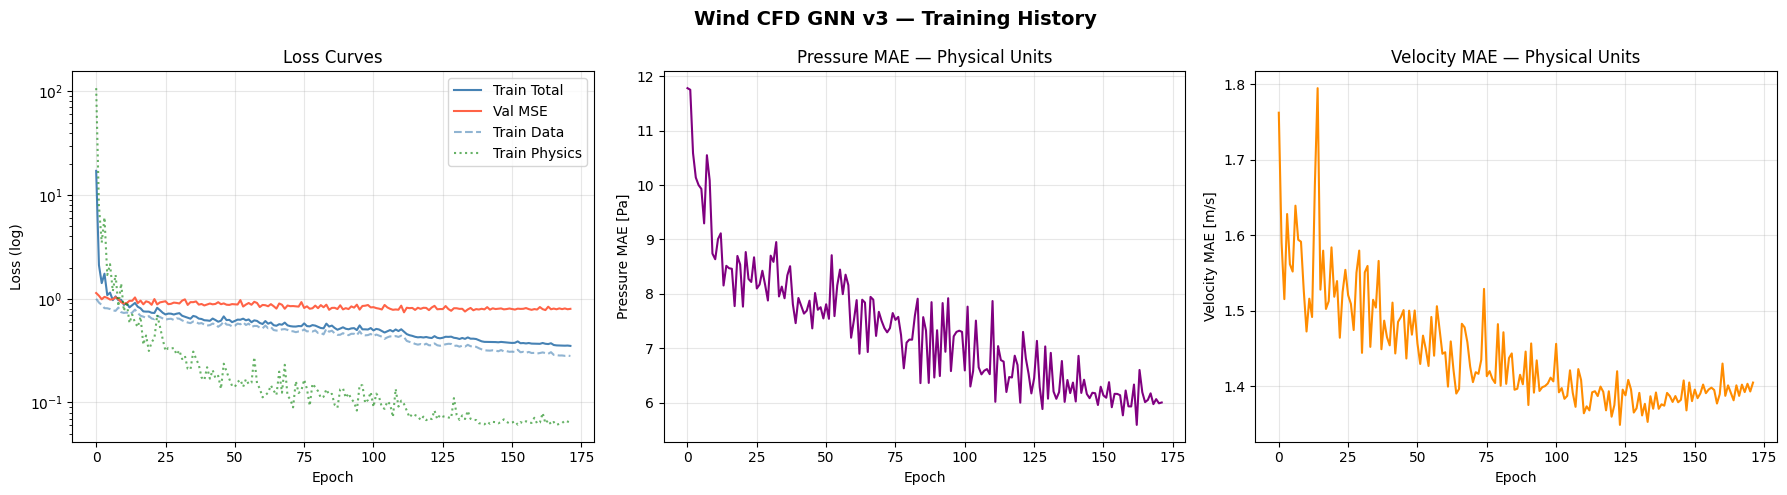

Saved training_curves.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Wind CFD GNN v3 — Training History', fontsize=14, fontweight='bold')

ax = axes[0]
ax.semilogy(history['train_total'], label='Train Total',   color='steelblue')
ax.semilogy(history['val_total'],   label='Val MSE',       color='tomato')
ax.semilogy(history['train_data'],  label='Train Data',    color='steelblue', ls='--', alpha=0.6)
ax.semilogy(history['train_phys'],  label='Train Physics', color='green',     ls=':',  alpha=0.6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)'); ax.set_title('Loss Curves')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history['val_p_mae_Pa'], color='purple')
ax.set_xlabel('Epoch'); ax.set_ylabel('Pressure MAE [Pa]')
ax.set_title('Pressure MAE — Physical Units'); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(history['val_u_mae_ms'], color='darkorange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Velocity MAE [m/s]')
ax.set_title('Velocity MAE — Physical Units'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 14 — Test Set Evaluation

In [16]:
# [L-2] n_params inline, no dependency on earlier cell
ckpt       = torch.load(ckpt_path, map_location=DEVICE)
eval_model = WindGNN(
    node_in_dim=ckpt.get('node_in_dim', NODE_IN_DIM),
    edge_in_dim=ckpt.get('edge_in_dim', EDGE_IN_DIM),
).to(DEVICE)
eval_model.load_state_dict(ckpt['model_state'])
eval_model.eval()
print(f"Best model from epoch {ckpt['epoch']}  val_MSE={ckpt['val_loss']:.6f}")
print(f"  Val p_MAE={ckpt['val_p_mae_Pa']:.2f} Pa  U_MAE={ckpt['val_u_mae_ms']:.3f} m/s")
n_params_eval = sum(p.numel() for p in eval_model.parameters())
print(f'  Params: {n_params_eval:,}')


@torch.no_grad()
def evaluate_test(loader, m):
    results = []
    for batch in loader:
        batch = batch.to(DEVICE)
        pred  = m(batch).cpu().numpy()
        y     = batch.y.cpu().numpy()
        pos   = batch.pos.cpu().numpy()

        p_pred_kin = pred[:, 0] * NORM['p_std'] + NORM['p_mean']
        p_true_kin = y[:, 0]   * NORM['p_std'] + NORM['p_mean']
        p_pred_Pa  = p_pred_kin * RHO
        p_true_Pa  = p_true_kin * RHO

        U_pred = np.stack([
            pred[:, 1] * NORM['Ux_std'] + NORM['Ux_mean'],
            pred[:, 2] * NORM['Uy_std'] + NORM['Uy_mean'],
            pred[:, 3] * NORM['Uz_std'] + NORM['Uz_mean'],
        ], axis=1)
        U_true = np.stack([
            y[:, 1] * NORM['Ux_std'] + NORM['Ux_mean'],
            y[:, 2] * NORM['Uy_std'] + NORM['Uy_mean'],
            y[:, 3] * NORM['Uz_std'] + NORM['Uz_mean'],
        ], axis=1)
        um_p = np.linalg.norm(U_pred, axis=1)
        um_t = np.linalg.norm(U_true, axis=1)

        results.append({
            'p_mae_Pa':  np.abs(p_pred_Pa - p_true_Pa).mean(),
            'p_rmse_Pa': np.sqrt(((p_pred_Pa - p_true_Pa)**2).mean()),
            'u_mae_ms':  np.abs(um_p - um_t).mean(),
            'u_rmse_ms': np.sqrt(((um_p - um_t)**2).mean()),
            'p_pred_Pa': p_pred_Pa, 'p_true_Pa': p_true_Pa,
            'U_pred': U_pred, 'U_true': U_true, 'pos': pos,
        })
    return results


test_results = evaluate_test(test_loader, eval_model)
print(f'\n── Test Set Results ──')
print(f'{"Case":>4}  {"p_MAE [Pa]":>12}  {"p_RMSE [Pa]":>13}  '
      f'{"U_MAE [m/s]":>12}  {"U_RMSE [m/s]":>13}')
print('-' * 60)
for i, r in enumerate(test_results):
    print(f'{i+1:>4}  {r["p_mae_Pa"]:>12.2f}  {r["p_rmse_Pa"]:>13.2f}  '
          f'{r["u_mae_ms"]:>12.3f}  {r["u_rmse_ms"]:>13.3f}')
avg_p = np.mean([r['p_mae_Pa'] for r in test_results])
avg_u = np.mean([r['u_mae_ms'] for r in test_results])
print(f'\n  AVG  p_MAE={avg_p:.2f} Pa  U_MAE={avg_u:.3f} m/s')

Best model from epoch 112  val_MSE=0.739841
  Val p_MAE=6.01 Pa  U_MAE=1.374 m/s
  Params: 702,628

── Test Set Results ──
Case    p_MAE [Pa]    p_RMSE [Pa]   U_MAE [m/s]   U_RMSE [m/s]
------------------------------------------------------------
   1          3.37           4.70         0.784          1.046
   2          6.32           8.22         0.936          1.241
   3          4.99           6.79         0.803          1.103
   4          2.76           3.03         0.406          0.551
   5          2.39           3.51         0.573          0.694
   6          3.92           5.02         0.657          0.814
   7          2.99           3.47         0.362          0.492
   8          6.00           7.91         0.932          1.131
   9          9.95          12.61         0.891          1.202

  AVG  p_MAE=4.74 Pa  U_MAE=0.705 m/s


## 15 — Prediction Visualization

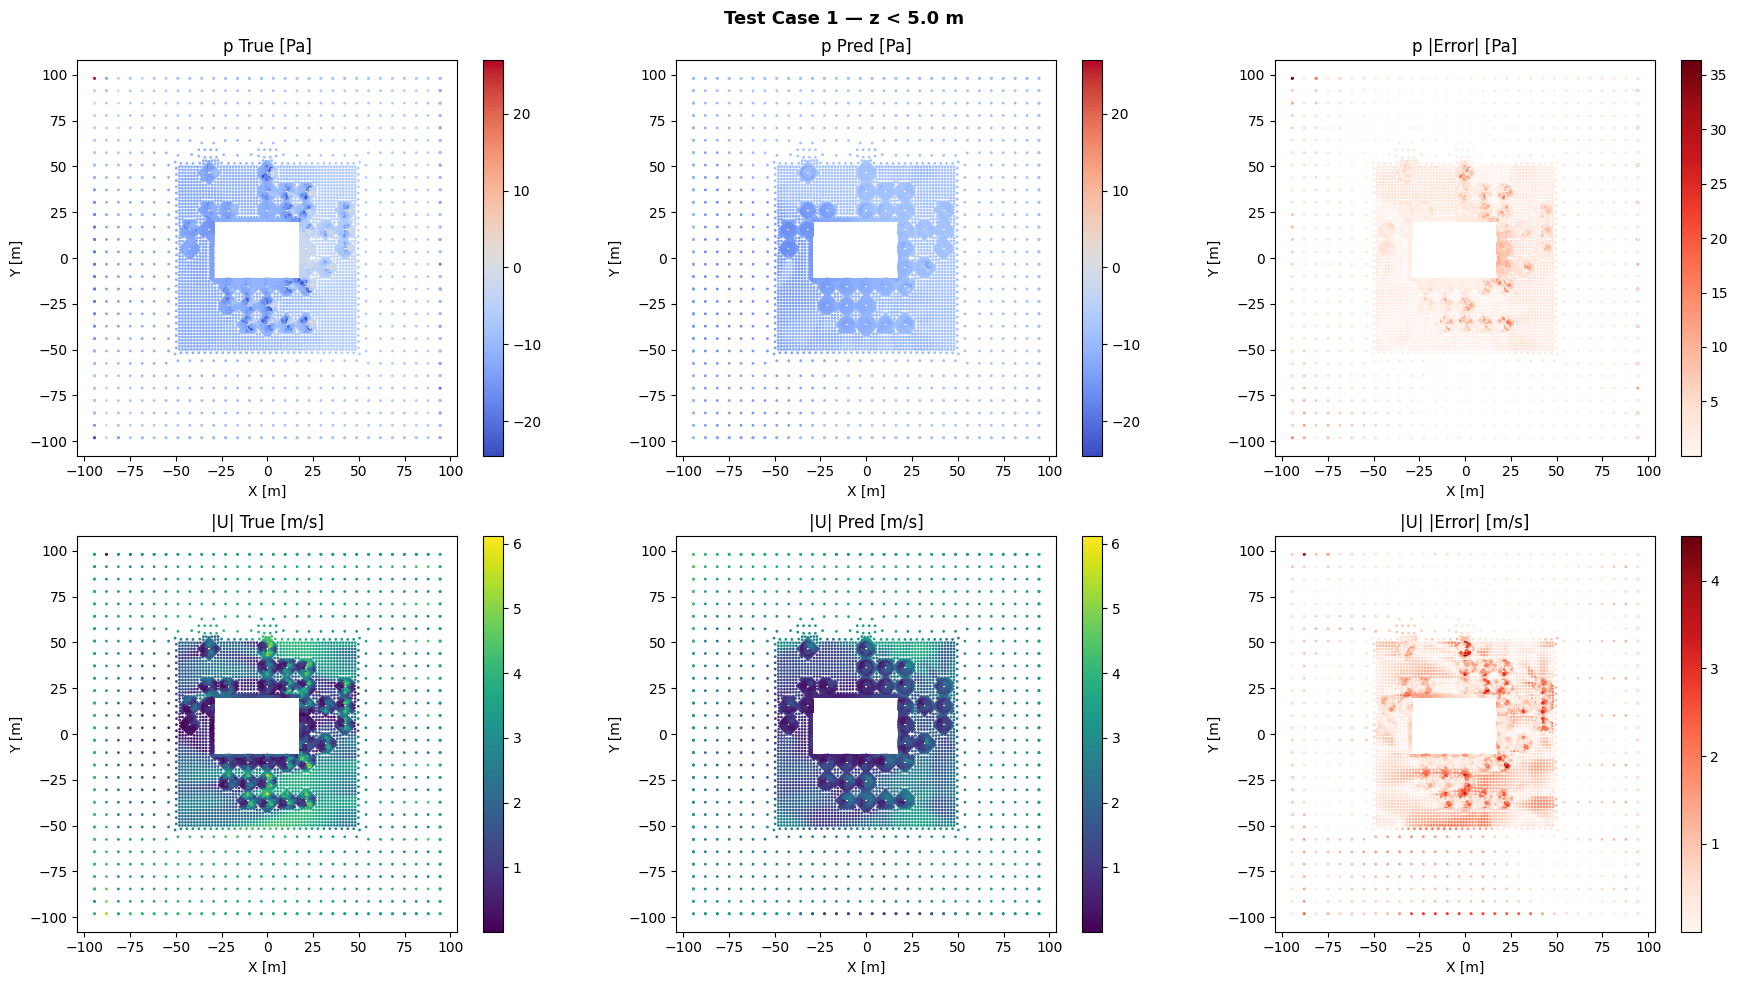

Saved /kaggle/working/output/test_case_1_comparison.png


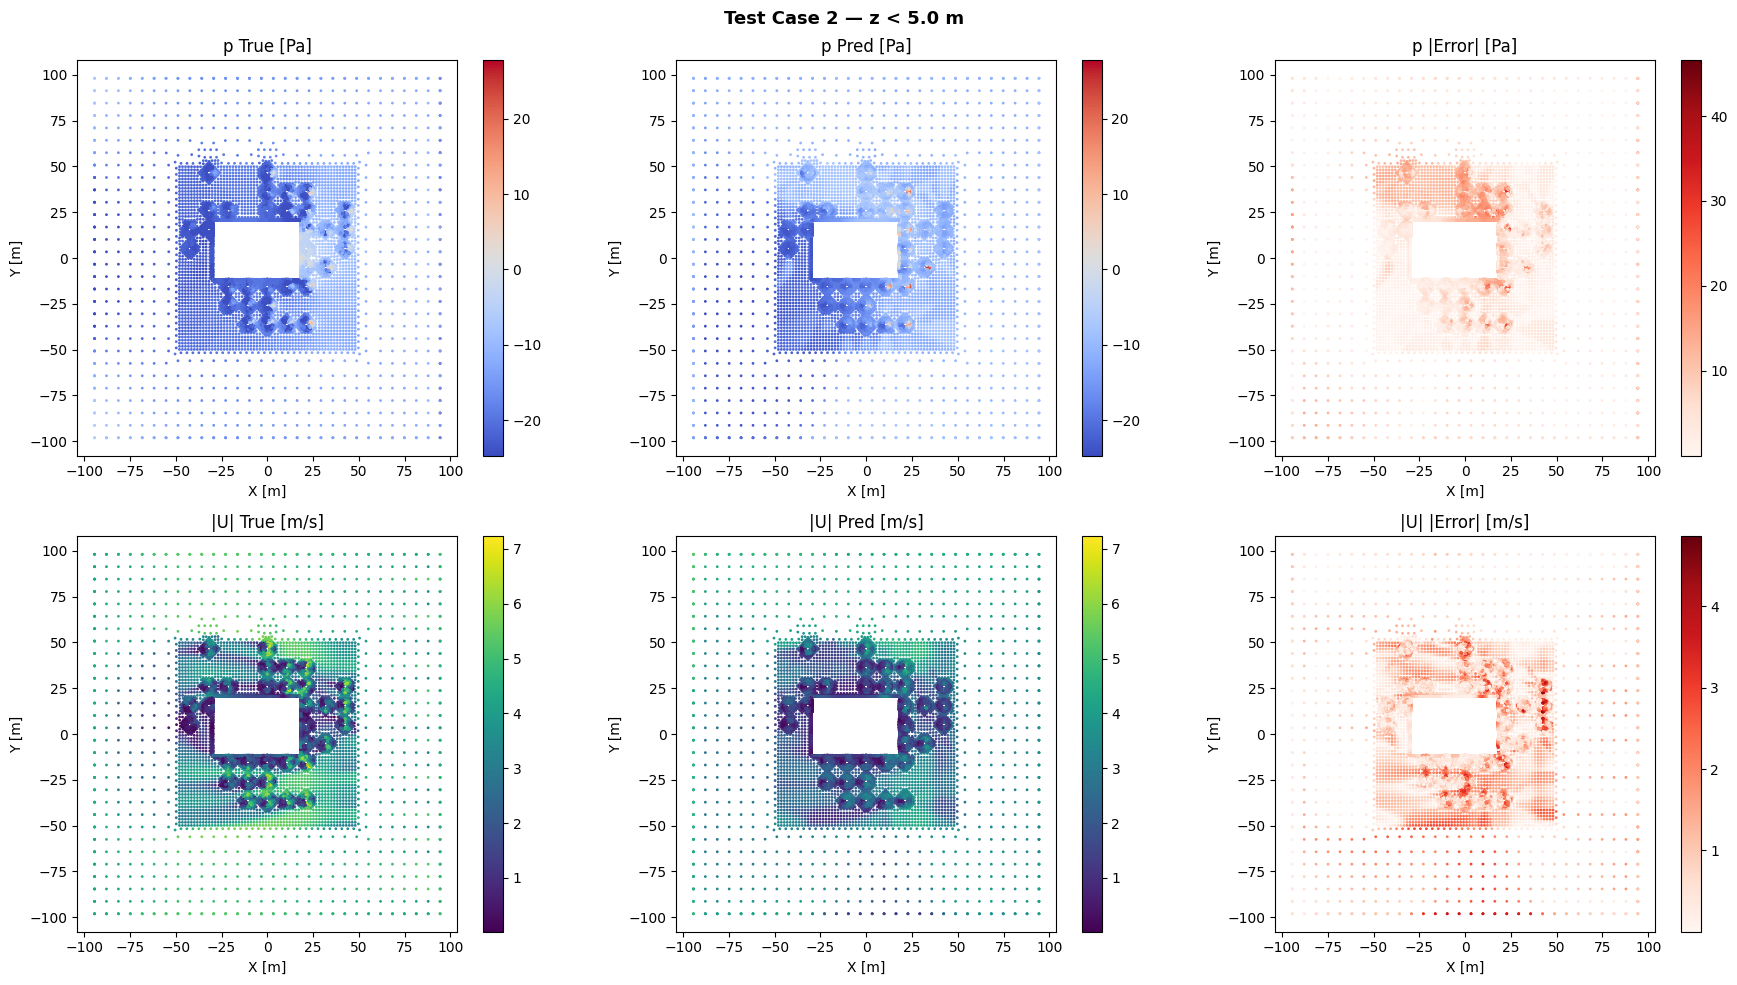

Saved /kaggle/working/output/test_case_2_comparison.png


In [17]:
def plot_comparison(result: Dict, case_idx: int, z_cut: float = 5.0):
    pos  = result['pos']
    mask = pos[:, 2] < z_cut
    if mask.sum() < 50:
        mask = np.ones(len(pos), dtype=bool)
    x, y = pos[mask, 0], pos[mask, 1]
    pp, pt = result['p_pred_Pa'][mask], result['p_true_Pa'][mask]
    up = np.linalg.norm(result['U_pred'][mask], axis=1)
    ut = np.linalg.norm(result['U_true'][mask], axis=1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Test Case {case_idx+1} — z < {z_cut} m', fontsize=13, fontweight='bold')

    def scat(ax, xv, yv, val, title, cmap='coolwarm', vmin=None, vmax=None):
        sc = ax.scatter(xv, yv, c=val, cmap=cmap, s=1,
                        vmin=vmin or val.min(), vmax=vmax or val.max())
        plt.colorbar(sc, ax=ax, fraction=0.04)
        ax.set_title(title); ax.set_aspect('equal')
        ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')

    pm, px = min(pp.min(), pt.min()), max(pp.max(), pt.max())
    um, ux = min(up.min(), ut.min()), max(up.max(), ut.max())
    scat(axes[0,0], x, y, pt,            'p True [Pa]',       vmin=pm, vmax=px)
    scat(axes[0,1], x, y, pp,            'p Pred [Pa]',       vmin=pm, vmax=px)
    scat(axes[0,2], x, y, np.abs(pp-pt), 'p |Error| [Pa]',    cmap='Reds')
    scat(axes[1,0], x, y, ut,            '|U| True [m/s]',    cmap='viridis', vmin=um, vmax=ux)
    scat(axes[1,1], x, y, up,            '|U| Pred [m/s]',    cmap='viridis', vmin=um, vmax=ux)
    scat(axes[1,2], x, y, np.abs(up-ut), '|U| |Error| [m/s]', cmap='Reds')

    plt.tight_layout()
    out = OUTPUT_DIR / f'test_case_{case_idx+1}_comparison.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {out}')


for i, res in enumerate(test_results[:2]):
    plot_comparison(res, i)

## 16 — Production Inference Pipeline (All Bugs Fixed)

**[H-3]** Fixed `trimesh.proximity.closest_point` unpacking (`_, distances, face_ids`)  
**[M-6]** `CFDInference` takes explicit `ckpt_path` — no hidden dependency  
**[L-4]** Weak/wake thresholds from config block

In [18]:
class CFDInference:
    """
    Production inference: .obj + Uinlet → p field [Pa] + U field [m/s]

    All config thresholds (WEAK_ZONE_FRAC, WAKE_SPEED_FRAC, BL_HEIGHT_M)
    come from the config block — no magic numbers.
    """

    def __init__(self, ckpt_path: Path, norm_path: Path,
                 device: torch.device = DEVICE):
        with open(norm_path) as f:
            self.norm = json.load(f)
        ckpt = torch.load(str(ckpt_path), map_location=device)
        n_in = ckpt.get('node_in_dim', NODE_IN_DIM)
        e_in = ckpt.get('edge_in_dim', EDGE_IN_DIM)
        # [M-4] Load into plain WindGNN (not DataParallel)
        self.model = WindGNN(node_in_dim=n_in, edge_in_dim=e_in).to(device)
        self.model.load_state_dict(ckpt['model_state'])
        self.model.eval()
        self.device = device
        print(f"Inference model loaded — epoch {ckpt['epoch']}  node_in={n_in}  edge_in={e_in}  (v9: 20 node dims)")

    def _sample_domain(self, obj_path: Path,
                        n_surface: int, n_volume: int) -> np.ndarray:
        mesh   = trimesh.load(str(obj_path), force='mesh')
        bounds = mesh.bounds
        bsize  = bounds[1] - bounds[0]
        margin = np.array([3.0 * bsize[0], 3.0 * bsize[1], 2.0 * bsize[2]])

        # Surface samples
        s_pts, _ = trimesh.sample.sample_surface(mesh, n_surface)
        # [H-3] FIXED: correct unpacking — (points, distances, face_ids)
        _, distances, face_ids = trimesh.proximity.closest_point(mesh, s_pts)
        norms  = mesh.face_normals
        s_pts  = s_pts + 0.10 * norms[face_ids]   # push 10cm outward

        # Volume samples
        lo    = bounds[0] - margin
        hi    = bounds[1] + margin
        v_pts = np.random.uniform(lo, hi, (n_volume, 3))

        return np.vstack([s_pts, v_pts]).astype(np.float32)

    def predict(self, obj_path: Path, inlet_velocity: List[float],
                n_points: int = 30000) -> Dict:
        norm  = self.norm
        inlet = np.array(inlet_velocity, dtype=np.float32)
        pts_r = self._sample_domain(obj_path,
                                     n_surface=n_points // 3,
                                     n_volume=n_points - n_points // 3)
        N = len(pts_r)

        # Normalize coordinates
        pts_n = np.stack([
            (pts_r[:, 0] - norm['x_mean']) / norm['x_std'],
            (pts_r[:, 1] - norm['y_mean']) / norm['y_std'],
            (pts_r[:, 2] - norm['z_mean']) / norm['z_std'],
        ], axis=1).astype(np.float32)

        Ui_mean       = np.array(norm['Ui_mean'], dtype=np.float32)
        Ui_std        = np.array(norm['Ui_std'],  dtype=np.float32)
        ui_n          = (inlet - Ui_mean) / Ui_std
        inlet_speed_n = float(
            (np.linalg.norm(inlet) - norm['Ui_speed_mean']) / norm['Ui_speed_std']
        )

        # Node features — must match training EXACTLY (20 dims, v9)
        ui_broadcast  = np.tile(ui_n, (N, 1))
        inlet_speed_f = np.full((N, 1), inlet_speed_n, dtype=np.float32)
        z_max         = float(pts_r[:, 2].max()) + 1e-6
        z_norm        = np.clip(pts_r[:, 2:3] / z_max, 0, 1).astype(np.float32)
        centroid      = pts_n.mean(axis=0, keepdims=True)
        dist_center   = np.linalg.norm(pts_n - centroid, axis=1,
                                        keepdims=True).astype(np.float32)
        ground_flag   = (1.0 / (1.0 + np.exp(20.0 * z_norm))).astype(np.float32)
        # Boundary flags: all zeros for inference (no mesh topology info)
        zeros_4     = np.zeros((N, 4), dtype=np.float32)  # is_bld, is_gnd, is_in, is_out
        dist_to_bld = np.ones((N, 1), dtype=np.float32)   # 1.0 = far from any building
        ui_unit_n   = ui_n / (np.linalg.norm(ui_n) + 1e-8)
        wind_align  = (pts_n @ ui_unit_n).reshape(-1, 1).astype(np.float32)

        # [PRE-3] cos/sin inlet angle (inference)
        angle_rad  = float(np.arctan2(inlet[1], inlet[0]))
        inlet_cos  = np.full((N, 1), np.cos(angle_rad), dtype=np.float32)
        inlet_sin  = np.full((N, 1), np.sin(angle_rad), dtype=np.float32)

        # [PRE-4] ABL power-law height profile (inference)
        z_raw     = pts_r[:, 2:3].clip(min=0.01)
        abl_ratio = np.clip((z_raw / ABL_Z_REF) ** ABL_ALPHA, 0.0, 3.0).astype(np.float32)

        # [PRE-2] TKE: zero for inference (no CFD mesh available)
        k_feat = np.zeros((N, 1), dtype=np.float32)

        x_node = np.concatenate([
            pts_n,         # 0-2  normalized coords
            ui_broadcast,  # 3-5  inlet velocity
            inlet_speed_f, # 6    inlet speed
            z_norm,        # 7    height 0→1
            dist_center,   # 8    dist from centroid
            ground_flag,   # 9    ground proximity
            zeros_4,       # 10-13 boundary flags (is_bld, is_gnd, is_in, is_out)
            dist_to_bld,   # 14   dist to building
            wind_align,    # 15   wind alignment
            inlet_cos,     # 16   [PRE-3] cos(angle)
            inlet_sin,     # 17   [PRE-3] sin(angle)
            abl_ratio,     # 18   [PRE-4] ABL ratio
            k_feat,        # 19   [PRE-2] TKE (0 for inference)
        ], axis=1).astype(np.float32)   # (N, 20) — matches training v9

        # k-NN graph
        tree     = cKDTree(pts_n)
        _, idxs  = tree.query(pts_n, k=K_NEIGHBORS + 1)
        src = np.repeat(np.arange(N), K_NEIGHBORS)
        dst = idxs[:, 1:].reshape(-1)
        rel_disp    = pts_n[dst] - pts_n[src]
        rel_dist    = np.linalg.norm(rel_disp, axis=1, keepdims=True)
        foam_flag   = np.zeros((len(src), 1), dtype=np.float32)  # 0 = no mesh info
        # [FIX-INF2] Wind projection edge feature (matches training 6-dim)
        rel_disp_r  = pts_r[dst] - pts_r[src]  # raw [m]
        ui_unit_raw = inlet / (np.linalg.norm(inlet) + 1e-8)
        wind_proj   = rel_disp_r @ ui_unit_raw  # (E,)
        wind_proj_n = (wind_proj / (rel_dist.squeeze() + 1e-4)).reshape(-1, 1)
        edge_attr   = np.concatenate([rel_disp, rel_dist, foam_flag, wind_proj_n], axis=1)
        # (E, 6) — matches training

        data = Data(
            x          = torch.tensor(x_node,                  dtype=torch.float32),
            edge_index = torch.tensor(np.stack([src, dst]),    dtype=torch.long),
            edge_attr  = torch.tensor(edge_attr,               dtype=torch.float32),
            pos        = torch.tensor(pts_r,                   dtype=torch.float32),
        ).to(self.device)

        with torch.no_grad():
            pred = self.model(data).cpu().numpy()   # (N, 4) normalized

        # De-normalize
        p_kin = pred[:, 0] * norm['p_std'] + norm['p_mean']    # [m²/s²]
        U_ms  = np.stack([
            pred[:, 1] * norm['Ux_std'] + norm['Ux_mean'],
            pred[:, 2] * norm['Uy_std'] + norm['Uy_mean'],
            pred[:, 3] * norm['Uz_std'] + norm['Uz_mean'],
        ], axis=1)
        # [FIX-INF3] p_kin is GAUGE kinematic [m²/s²] (trained on p - P_REF)
        # p_gauge_Pa = p_kin * RHO  [Pa gauge]
        # p_abs_Pa   = p_gauge_Pa + P_REF  [Pa absolute]
        p_gauge_Pa = p_kin * RHO          # gauge dynamic pressure [Pa]
        p_abs_Pa   = p_gauge_Pa + P_REF   # absolute pressure [Pa]
        u_mag      = np.linalg.norm(U_ms, axis=1)
        inp_spd    = np.linalg.norm(inlet)

        # ── Flow diagnostics ──────────────────────────────────────────────
        weak_mask  = u_mag < WEAK_ZONE_FRAC * inp_spd
        bld_cen    = pts_r.mean(axis=0)
        inlet_dir  = inlet / (inp_spd + 1e-8)
        along_flow = (pts_r - bld_cen) @ inlet_dir
        wake_mask  = (along_flow > WAKE_DOWNSTREAM_M) & (u_mag < WAKE_SPEED_FRAC * inp_spd)
        bl_mask    = pts_r[:, 2] < BL_HEIGHT_M

        return {
            'points':         pts_r,
            'p_kinematic':    p_kin,          # gauge kinematic [m²/s²]
            'p_Pa':           p_abs_Pa,        # absolute pressure [Pa]
            'p_gauge_Pa':     p_gauge_Pa,      # gauge pressure [Pa]
            'U_ms':           U_ms,            # velocity [m/s]
            'U_mag_ms':       u_mag,
            'weak_zone_mask': weak_mask,
            'wake_mask':      wake_mask,
            'boundary_layer': bl_mask,
        }


# [M-6] Instantiate with explicit ckpt_path
inferencer = CFDInference(
    ckpt_path = ckpt_path,
    norm_path = OUTPUT_DIR / 'normalization.json',
)
print('Inference pipeline ready.')

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/output/normalization.json'

## 17 — Demo Inference

In [19]:
DEMO_OBJ = None
objs = list(DATASET_ROOT.rglob('buildings.obj'))
if objs:
    DEMO_OBJ = objs[0]
    print(f'Using OBJ: {DEMO_OBJ}')
else:
    print('No OBJ found — skipping demo')

if DEMO_OBJ is not None:
    result = inferencer.predict(
        obj_path       = DEMO_OBJ,
        inlet_velocity = [2.83, 2.83, 0.0],   # SW wind at 4 m/s
        n_points       = 25000,
    )
    print(f'\n── Prediction Summary ──')
    print(f'  Points:          {len(result["points"]):,}')
    print(f'  p range:         {result["p_Pa"].min():.1f} – {result["p_Pa"].max():.1f} Pa')
    print(f'  Gauge p range:   {result["p_gauge_Pa"].min():.1f} – {result["p_gauge_Pa"].max():.1f} Pa')
    print(f'  Wind speed:      {result["U_mag_ms"].min():.2f} – {result["U_mag_ms"].max():.2f} m/s')
    print(f'  Weak zones:      {result["weak_zone_mask"].sum():,} ({100*result["weak_zone_mask"].mean():.1f}%)')
    print(f'  Wake region:     {result["wake_mask"].sum():,} ({100*result["wake_mask"].mean():.1f}%)')
    print(f'  Boundary layer:  {result["boundary_layer"].sum():,} ({100*result["boundary_layer"].mean():.1f}%)')

    pts  = result['points']
    mask = pts[:, 2] < 5.0
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('GNN Inference — Horizontal Slice (z < 5 m)', fontsize=13, fontweight='bold')

    sc0 = axes[0].scatter(pts[mask,0], pts[mask,1],
                          c=result['p_gauge_Pa'][mask], cmap='RdBu_r', s=2)
    plt.colorbar(sc0, ax=axes[0], label='Gauge Pressure [Pa]')
    axes[0].set_title('Pressure Field'); axes[0].set_aspect('equal')

    sc1 = axes[1].scatter(pts[mask,0], pts[mask,1],
                          c=result['U_mag_ms'][mask], cmap='viridis', s=2)
    plt.colorbar(sc1, ax=axes[1], label='Wind Speed [m/s]')
    axes[1].set_title('Velocity Magnitude'); axes[1].set_aspect('equal')

    weak_m = mask & result['weak_zone_mask']
    wake_m = mask & result['wake_mask']
    axes[2].scatter(pts[mask,0], pts[mask,1], c=result['U_mag_ms'][mask],
                    cmap='viridis', s=2, alpha=0.4)
    axes[2].scatter(pts[weak_m,0], pts[weak_m,1], c='red',    s=4, label=f'Weak <{WEAK_ZONE_FRAC*100:.0f}%', alpha=0.7)
    axes[2].scatter(pts[wake_m,0], pts[wake_m,1], c='orange', s=4, label=f'Wake <{WAKE_SPEED_FRAC*100:.0f}%', alpha=0.5)
    axes[2].legend(markerscale=3); axes[2].set_title('Flow Zones'); axes[2].set_aspect('equal')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'demo_inference.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved demo_inference.png')

Using OBJ: /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mohali_summer/building2/constant/triSurface/buildings.obj


NameError: name 'inferencer' is not defined

## 18 — Export OpenFOAM-Format p and U Files

**[M-7]** Fixed: includes required `boundaryField` section so ParaView / OpenFOAM tools load correctly.

In [ ]:
def write_foam_scalar(filepath: Path, values: np.ndarray,
                       field_name: str = 'p',
                       dimensions: str = '[0 2 -2 0 0 0 0]',
                       patch_names: Optional[List[str]] = None):
    """[M-7] Write OpenFOAM ASCII scalar field WITH boundaryField section."""
    n = len(values)
    patches = patch_names or ['inlet', 'outlet', 'ground', 'top', 'buildings']
    with open(filepath, 'w') as f:
        f.write('FoamFile\n{\n')
        f.write('    version     2.0;\n')
        f.write('    format      ascii;\n')
        f.write(f'    class       volScalarField;\n')
        f.write(f'    object      {field_name};\n}}\n\n')
        f.write(f'dimensions      {dimensions};\n\n')
        f.write(f'internalField   nonuniform List<scalar>\n{n}\n(\n')
        for v in values:
            f.write(f'{v:.8g}\n')
        f.write(');\n\nboundaryField\n{\n')
        for p in patches:
            f.write(f'    {p}\n    {{\n        type    zeroGradient;\n    }}\n')
        f.write('}\n\n// *********************************************** //\n')
    print(f'Written: {filepath}  ({n} values, with boundaryField)')


def write_foam_vector(filepath: Path, values: np.ndarray,
                       field_name: str = 'U',
                       dimensions: str = '[0 1 -1 0 0 0 0]',
                       patch_names: Optional[List[str]] = None):
    """[M-7] Write OpenFOAM ASCII vector field WITH boundaryField section."""
    n = len(values)
    patches = patch_names or ['inlet', 'outlet', 'ground', 'top', 'buildings']
    with open(filepath, 'w') as f:
        f.write('FoamFile\n{\n')
        f.write('    version     2.0;\n')
        f.write('    format      ascii;\n')
        f.write(f'    class       volVectorField;\n')
        f.write(f'    object      {field_name};\n}}\n\n')
        f.write(f'dimensions      {dimensions};\n\n')
        f.write(f'internalField   nonuniform List<vector>\n{n}\n(\n')
        for v in values:
            f.write(f'({v[0]:.8g} {v[1]:.8g} {v[2]:.8g})\n')
        f.write(');\n\nboundaryField\n{\n')
        for p in patches:
            f.write(f'    {p}\n    {{\n        type    zeroGradient;\n    }}\n')
        f.write('}\n\n// *********************************************** //\n')
    print(f'Written: {filepath}  ({n} vectors, with boundaryField)')


if 'result' in dir() and result is not None:
    write_foam_scalar(OUTPUT_DIR / 'p', result['p_kinematic'], field_name='p')
    write_foam_vector(OUTPUT_DIR / 'U', result['U_ms'],        field_name='U')
    np.savetxt(OUTPUT_DIR / 'predicted_cell_centers.csv',
               result['points'], delimiter=',', header='x,y,z', comments='')
    print('\nOpenFOAM-ready files written to:', OUTPUT_DIR)
    print('  p  — kinematic pressure [m²/s²]')
    print('  U  — velocity vector [m/s]')
    print('  predicted_cell_centers.csv — point coordinates')
    print('  boundaryField included — load in ParaView with OpenFOAM reader')

## 19 — Run Summary

In [ ]:
print('=' * 70)
print('  Wind CFD GNN v9 Surrogate — v8 + Data Preprocessing Improvements')
print('=' * 70)
print(f'  Dataset cases:         {len(raw_cases)}')
print(f'  Train / Val / Test:    {n_train} / {n_val} / {n_test}')
n_p = sum(p.numel() for p in eval_model.parameters())
print(f'  Model parameters:      {n_p:,}')
print(f'  NODE_IN_DIM:           {NODE_IN_DIM}  (auto-detected)')
print(f'  EDGE_IN_DIM:           {EDGE_IN_DIM}  (auto-detected)')
print(f'  Best val MSE:          {best_val:.6f}')
if test_results:
    print(f'  Test p MAE:            {avg_p:.2f} Pa')
    print(f'  Test U MAE:            {avg_u:.3f} m/s')
print()
print('  Key fixes summary:')
print('    Parsers      : count-based extraction (C-2, C-3) ✓')
print('    Cell centers : nCells from header note (H-1, H-2) ✓')
print('    Graph        : k-NN + is_foam_neighbor edge flag ✓')
print()
print('  v9 Preprocessing fixes:')
print('    [PRE-1] Outlier clipping 0.5-99.5% (p, U) ✓')
print('    [PRE-2] TKE (k) node feature ✓')
print('    [PRE-3] cos/sin inlet angle encoding ✓')
print('    [PRE-4] ABL power-law height profile ✓')
print('    [PRE-5] Boundary-preserving subsampling ✓')
print('    [PRE-6] Gradient-weighted data loss ✓')
print('    Boundary     : is_building/ground/inlet/outlet node features ✓')
print('    Physics loss : kinematic units, wall damping (H-4) ✓')
print('    DataParallel : device-safe pos/edge_index (C-4) ✓')
print('    Inference    : trimesh unpacking fixed (H-3) ✓')
print('    OpenFOAM out : boundaryField included (M-7) ✓')
print('    Cache        : norm-hash invalidation (H-6) ✓')
print('    Split        : deterministic stratified (C-5) ✓')
print('    Training log : physical units Pa/m/s (M-3) ✓')
print()
print('  Inference API:')
print('    result = inferencer.predict(')
print('        obj_path       = Path("building.obj"),')
print('        inlet_velocity = [Ux, Uy, 0.0],   # m/s')
print('    )')
print()
print('  Output files:')
for fp in sorted(OUTPUT_DIR.iterdir()):
    sz = fp.stat().st_size / 1024
    print(f'    {fp.name:<45} {sz:.1f} KB')